# Advanced Data Analytics - EDA auf dem Porto Seguro OpenML-Datensatz

## Ablauf

**Teil A - Laden und Prüfen des vollständigen Datensatzes**

1. Importe
2. Datenpfad definieren
3. Daten laden
4. Daten validieren (Integritätsprüfung)

**Teil B - Erkundung auf dem vollständigen Datensatz**

1. Beispieldaten und Merkmalsinventar
2. Korrelationen numerischer Daten
3. Zielvariable – univariate Beschreibung
4. Missing Values auf dem vollständigen Datensatz
5. Univariate Verteilungen der Features

**Teil C - EDA nach dem Datensatzsplit**

1. Datensplit prüfen und laden
2. Zusammenhang fehlende Werte mit dem Target
3.  Hinweis auf potenziell künstliche oder transformierte Daten 
4. Suche nach künstlichen Transformationen
5. Binärfeatures auf Muster überprüfen
6. Signal- und Driftprüfung
7. Kardinalitätsanalyse ausgewählter kategorialer Features
8. Analyse ausgewählter Target-Zusammenhänge (Nachtrag zu 2)
9. Binärfeatures und Schadensquote (Nachtrag zu 2)
10. Gemeinsame Risikostruktur korrelierter numerischer Features

**Teil D - EDA Zusammenfassung und mögliche Hypothesen**

## **Teil A - Laden und Prüfen des vollständigen Datensatzes**

## 1. Importe

In [23]:
from IPython.display import display
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(context="notebook", style="whitegrid")

## 2. Datenpfad definieren

In [8]:
DATA_FILE = Path("dataset.parquet")

OUTPUT_DIR = Path("../research/eda")
OUTPUT_DIR.mkdir(exist_ok=True)

GENERATED_DIR = OUTPUT_DIR / "generated"

## 3. Daten laden

In [9]:
df = pd.read_parquet(DATA_FILE)

print("Form:", df.shape)

Form: (595212, 58)


## 4. Daten validieren (Integritätsprüfung)

In [11]:
target_column = "target"
feature_columns = df.columns.drop(target_column).to_list()

In [13]:
integrity_summary = pd.Series(
    {
        "Reihen": len(df),
        "Spalten": df.shape[1],
        "Features": len(feature_columns),
        "Doppelte Reihen": df.duplicated().sum(),
        "Doppelte Feature Reihen": (
            df[feature_columns].duplicated().sum()
        ),
        "Total Missing Values": df.isna().sum().sum(),
        "Spalten mit fehlenden Werten": df.isna().any().sum(),
        "Tatsächliche -1 Werte": (
            df.select_dtypes("number")
            .eq(-1)
            .sum()
            .sum()
        ),
    },
    name="value",
)

integrity_summary

Reihen                          595212
Spalten                             58
Features                            57
Doppelte Reihen                      0
Doppelte Feature Reihen              0
Total Missing Values            846458
Spalten mit fehlenden Werten        13
Tatsächliche -1 Werte                0
Name: value, dtype: int64

## **Teil B - Erkundung auf dem vollständigen Datensatz**

## 1. Beispieldaten und Merkmalsinventar

In [14]:
# a. Ein paar typische Zeilen ansehen und als CSV exportieren
sample_df = df.head(10)
sample_df.to_csv(OUTPUT_DIR / "01_initial_data_sample.csv", index=False)

# Anzeige im Notebook
sample_df

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2.0000,2.0000,5.0000,1.0000,0.0000,0,1,0,0,0,0,0,0,0.0000,11.0000,0,1,0,0.7000,0.2000,0.7181,10.0000,1.0000,NaN,0,1.0000,4,1.0000,0,0.0000,1,12,2.0000,0.4000,0.8837,0.3708,3.6056,0.6000,0.5000,0.2000,3.0000,1.0000,10.0000,1.0000,10.0000,1.0000,5.0000,9.0000,1.0000,5.0000,8.0000,0,1,1,0,0,1
1,0,1.0000,1.0000,7.0000,0.0000,0.0000,0,0,1,0,0,0,0,0,0.0000,3.0000,0,0,1,0.8000,0.4000,0.7661,11.0000,1.0000,NaN,0,NaN,11,1.0000,1,2.0000,1,19,3.0000,0.3162,0.6188,0.3887,2.4495,0.3000,0.1000,0.3000,2.0000,1.0000,9.0000,5.0000,8.0000,1.0000,7.0000,3.0000,1.0000,1.0000,9.0000,0,1,1,0,1,0
2,0,5.0000,4.0000,9.0000,1.0000,0.0000,0,0,1,0,0,0,0,0,0.0000,12.0000,1,0,0,0.0000,0.0000,NaN,7.0000,1.0000,NaN,0,NaN,14,1.0000,1,2.0000,1,60,1.0000,0.3162,0.6416,0.3473,3.3166,0.5000,0.7000,0.1000,2.0000,2.0000,9.0000,1.0000,8.0000,2.0000,7.0000,4.0000,2.0000,7.0000,7.0000,0,1,1,0,1,0
3,0,0.0000,1.0000,2.0000,0.0000,0.0000,1,0,0,0,0,0,0,0,0.0000,8.0000,1,0,0,0.9000,0.2000,0.5809,7.0000,1.0000,0.0000,0,1.0000,11,1.0000,1,3.0000,1,104,1.0000,0.3742,0.5429,0.2950,2.0000,0.6000,0.9000,0.1000,2.0000,4.0000,7.0000,1.0000,8.0000,4.0000,2.0000,2.0000,2.0000,4.0000,9.0000,0,0,0,0,0,0
4,0,0.0000,2.0000,0.0000,1.0000,0.0000,1,0,0,0,0,0,0,0,0.0000,9.0000,1,0,0,0.7000,0.6000,0.8408,11.0000,1.0000,NaN,0,NaN,14,1.0000,1,2.0000,1,82,3.0000,0.3161,0.5658,0.3651,2.0000,0.4000,0.6000,0.0000,2.0000,2.0000,6.0000,3.0000,10.0000,2.0000,12.0000,3.0000,1.0000,1.0000,3.0000,0,0,0,1,1,0
5,0,5.0000,1.0000,4.0000,0.0000,0.0000,0,0,0,1,0,0,0,0,0.0000,6.0000,1,0,0,0.9000,1.8000,2.3326,10.0000,0.0000,NaN,0,0.0000,14,1.0000,1,0.0000,1,104,2.0000,0.4460,0.8790,0.4062,3.0000,0.7000,0.8000,0.4000,3.0000,1.0000,8.0000,2.0000,11.0000,3.0000,8.0000,4.0000,2.0000,0.0000,9.0000,0,1,0,1,1,1
6,0,2.0000,1.0000,3.0000,1.0000,0.0000,0,1,0,0,0,0,0,0,0.0000,8.0000,1,0,0,0.6000,0.1000,0.6175,6.0000,1.0000,NaN,0,1.0000,11,1.0000,1,0.0000,1,99,2.0000,0.3162,0.6397,0.3688,3.1623,0.2000,0.6000,0.5000,2.0000,2.0000,8.0000,1.0000,8.0000,3.0000,10.0000,3.0000,0.0000,0.0000,10.0000,0,1,0,0,1,0
7,0,5.0000,1.0000,4.0000,0.0000,0.0000,1,0,0,0,0,0,0,0,0.0000,13.0000,1,0,0,0.7000,0.4000,0.6072,11.0000,1.0000,0.0000,0,0.0000,11,1.0000,1,2.0000,1,30,3.0000,0.4470,0.9006,0.3748,3.3166,0.1000,0.5000,0.1000,1.0000,2.0000,7.0000,1.0000,6.0000,1.0000,13.0000,7.0000,1.0000,3.0000,6.0000,1,0,1,0,1,0
8,0,5.0000,1.0000,3.0000,1.0000,0.0000,0,0,1,0,0,0,0,0,0.0000,6.0000,1,0,0,0.9000,0.7000,0.9014,10.0000,1.0000,NaN,0,1.0000,14,1.0000,1,0.0000,1,68,3.0000,0.4000,0.7806,0.4074,2.8284,0.9000,0.8000,0.6000,3.0000,1.0000,7.0000,3.0000,9.0000,4.0000,11.0000,4.0000,2.0000,1.0000,5.0000,0,1,0,0,0,1
9,1,1.0000,1.0000,2.0000,0.0000,0.0000,0,1,0,0,0,0,0,0,0.0000,4.0000,0,0,1,0.9000,1.4000,2.3167,11.0000,0.0000,0.0000,1,0.0000,14,1.0000,1,2.0000,1,104,2.0000,0.4472,1.4582,0.3903,3.6056,0.7000,0.8000,0.8000,2.0000,2.0000,8.0000,2.0000,9.0000,1.0000,11.0000,3.0000,5.0000,0.0000,6.0000,0,1,0,0,1,0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          595212 non-null  int8   
 1   ps_ind_01       595212 non-null  float32
 2   ps_ind_02_cat   594996 non-null  float64
 3   ps_ind_03       595212 non-null  float32
 4   ps_ind_04_cat   595129 non-null  float64
 5   ps_ind_05_cat   589403 non-null  float64
 6   ps_ind_06_bin   595212 non-null  int64  
 7   ps_ind_07_bin   595212 non-null  int64  
 8   ps_ind_08_bin   595212 non-null  int64  
 9   ps_ind_09_bin   595212 non-null  int64  
 10  ps_ind_10_bin   595212 non-null  int64  
 11  ps_ind_11_bin   595212 non-null  int64  
 12  ps_ind_12_bin   595212 non-null  int64  
 13  ps_ind_13_bin   595212 non-null  int64  
 14  ps_ind_14       595212 non-null  float32
 15  ps_ind_15       595212 non-null  float32
 16  ps_ind_16_bin   595212 non-null  int64  
 17  ps_ind_17_bin   59521

In [15]:
df.describe()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,"595,212.0000","595,212.0000","594,996.0000","595,212.0000","595,129.0000","589,403.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","487,440.0000","595,105.0000","595,207.0000","183,981.0000","595,212.0000","328,661.0000","595,212.0000","583,723.0000","595,212.0000","594,643.0000","595,212.0000","595,212.0000","595,207.0000","595,211.0000","595,212.0000","552,592.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000","595,212.0000"
mean,0.0364,1.9004,1.3598,4.4233,0.4170,0.4190,0.3937,0.2570,0.1639,0.1853,0.0004,0.0017,0.0094,0.0009,0.0125,7.2999,0.6608,0.1211,0.1534,0.6110,0.4392,0.8940,8.2976,0.8299,0.6017,0.7252,0.5254,6.5553,0.9476,0.8321,1.3311,0.9921,62.2157,2.3461,0.3799,0.8133,0.3747,3.0659,0.4498,0.4496,0.4498,2.3721,1.8859,7.6894,3.0058,9.2259,2.3390,8.4336,5.4414,1.4419,2.8723,7.5390,0.1224,0.6278,0.5542,0.2872,0.3490,0.1533
std,0.1874,1.9838,0.6632,2.6999,0.4931,1.3500,0.4886,0.4370,0.3702,0.3885,0.0193,0.0411,0.0967,0.0308,0.1275,3.5460,0.4734,0.3262,0.3604,0.2876,0.4043,0.3454,2.5054,0.3757,0.4895,2.1535,0.4994,5.5014,0.2228,0.3738,0.9766,0.0916,33.0125,0.8325,0.0583,0.2246,0.0456,0.7314,0.2872,0.2869,0.2872,1.1172,1.1349,1.3343,1.4146,1.4597,1.2469,2.9046,2.3329,1.2030,1.6949,2.7467,0.3278,0.4834,0.4971,0.4524,0.4767,0.3603
min,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0612,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.1000,0.2506,0.1095,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,1.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,5.0000,0.0000,0.0000,0.0000,0.4000,0.2000,0.6334,7.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,32.0000,2.0000,0.3162,0.6709,0.3504,2.8284,0.2000,0.2000,0.2000,2.0000,1.0000,7.0000,2.0000,8.0000,1.0000,6.0000,4.0000,1.0000,2.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0000,1.0000,1.0000,4.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,7.0000,1.0000,0.0000,0.0000,0.7000,0.3000,0.8016,7.0000,1.0000,1.0000,0.0000,1.0000,7.0000,1.0000,1.0000,2.0000,1.0000,65.0000,3.0000,0.3742,0.7658,0.3735,3.3166,0.5000,0.4000,0.5000,2.0000,2.0000,8.0000,3.0000,9.0000,2.0000,8.0000,5.0000,1.0000,3.0000,7.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000
75%,0.0000,3.0000,2.0000,6.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,1.0000,0.0000,0.0000,0.9000,0.6000,1.0840,11.0000,1.0000,1.0000,0.0000,1.0000,11.0000,1.0000,1.0000,2.0000,1.0000,93.0000,3.0000,0.4000,0.9062,0.3981,3.6056,0.7000,0.7000,0.7000,3.0000,3.0000,9.0000,4.0000,10.0000,3.0000,10.0000,7

In [16]:
u=df.nunique(dropna=True); f=df.columns.to_series().astype(str).str.extract(r"^(ps_[^_]+)", expand=False).nunique(); print(f"{df.shape[0]:,} Zeilen, {df.shape[1]} Spalten | Missing gesamt: {df.isna().to_numpy().mean()*100:.2f}% | Kardinalität: {u.min()}–{u.max()} eindeutige Werte je Spalte | Summe Ausprägungen: {u.sum()} | Featurefamilien: {f}")

595,212 Zeilen, 58 Spalten | Missing gesamt: 2.45% | Kardinalität: 2–70416 eindeutige Werte je Spalte | Summe Ausprägungen: 76936 | Featurefamilien: 4


In [17]:
feature_index = pd.Index(
    feature_columns,
    name="feature",
)

role_labels_de = {
    "binary": "binär",
    "categorical": "kategorial",
    "numeric_or_ordinal": "numerisch/ordinal",
}

family_labels_de = {
    "individual": "Person/Fahrer:in (aus `ps_ind_*` abgeleitet)",
    "registration_or_region": (
        "Registrierung/Region "
        "(aus `ps_reg_*` abgeleitet; nicht eindeutig dokumentiert)"
    ),
    "car": "Fahrzeug (aus `ps_car_*` abgeleitet)",
    "calculated": "berechnet/anonymisiert (aus `ps_calc_*` abgeleitet)",
    "other": "sonstige/unklar",
}

In [18]:
# Merkmalsinventar
feature_inventory = (
    pd.DataFrame(index=feature_index)
    .assign(
        role=np.select(
            condlist=[
                feature_index.str.endswith("_cat"),
                feature_index.str.endswith("_bin"),
            ],
            choicelist=[
                "categorical",
                "binary",
            ],
            default="numeric_or_ordinal",
        ),
        family=np.select(
            condlist=[
                feature_index.str.startswith("ps_ind_"),
                feature_index.str.startswith("ps_reg_"),
                feature_index.str.startswith("ps_car_"),
                feature_index.str.startswith("ps_calc_"),
            ],
            choicelist=[
                "individual",
                "registration_or_region",
                "car",
                "calculated",
            ],
            default="other",
        ),
        pandas_dtype=[
            str(df[column].dtype)
            for column in feature_index
        ],
        non_missing_unique=[
            df[column].nunique(dropna=True)
            for column in feature_index
        ],
        missing_count=[
            df[column].isna().sum()
            for column in feature_index
        ],
        missing_rate=[
            df[column].isna().mean()
            for column in feature_index
        ],
    )
    .sort_values(
        [
            "role",
            "family",
            "feature",
        ]
    )
)

In [21]:
feature_inventory.to_csv(
    OUTPUT_DIR / "feature_inventory.csv"
)

feature_group_summary_de = (
    feature_inventory
    .assign(
        **{
            "Skalentyp / technische Rolle": lambda frame: (
                frame["role"].map(role_labels_de)
            ),
            "Vermutete Merkmalsgruppe": lambda frame: (
                frame["family"].map(family_labels_de)
            ),
        }
    )
    .groupby(
        [
            "Skalentyp / technische Rolle",
            "Vermutete Merkmalsgruppe",
        ],
        observed=True,
    )
    .size()
    .rename("Anzahl Merkmale")
    .reset_index()
)

In [22]:
feature_group_summary_de.to_csv(
    OUTPUT_DIR / "feature_inventory_DE.csv"
)

feature_group_summary_de

,Skalentyp / technische Rolle,Vermutete Merkmalsgruppe,Anzahl Merkmale
0,binär,Person/Fahrer:in (aus `ps_ind_*` abgeleitet),11
1,binär,berechnet/anonymisiert (aus `ps_calc_*` abgele...,6
2,kategorial,Fahrzeug (aus `ps_car_*` abgeleitet),11
3,kategorial,Person/Fahrer:in (aus `ps_ind_*` abgeleitet),3
4,numerisch/ordinal,Fahrzeug (aus `ps_car_*` abgeleitet),5
5,numerisch/ordinal,Person/Fahrer:in (aus `ps_ind_*` abgeleitet),4
6,numerisch/ordinal,Registrierung/Region (aus `ps_reg_*` abgeleite...,3
7,numerisch/ordinal,berechnet/anonymisiert (aus `ps_calc_*` abgele...,14


## 2. Korrelationen numerischer Daten

In [25]:
# Nur numerische/ordinale Features, ohne Target
numeric_plot_features = (
    df
    .select_dtypes(include=["number"])
    .columns
    .drop(target_column)
    .to_list()
)

numeric_df = df[numeric_plot_features]

In [26]:
# Pearson-Korrelationen
corr_matrix = numeric_df.corr()

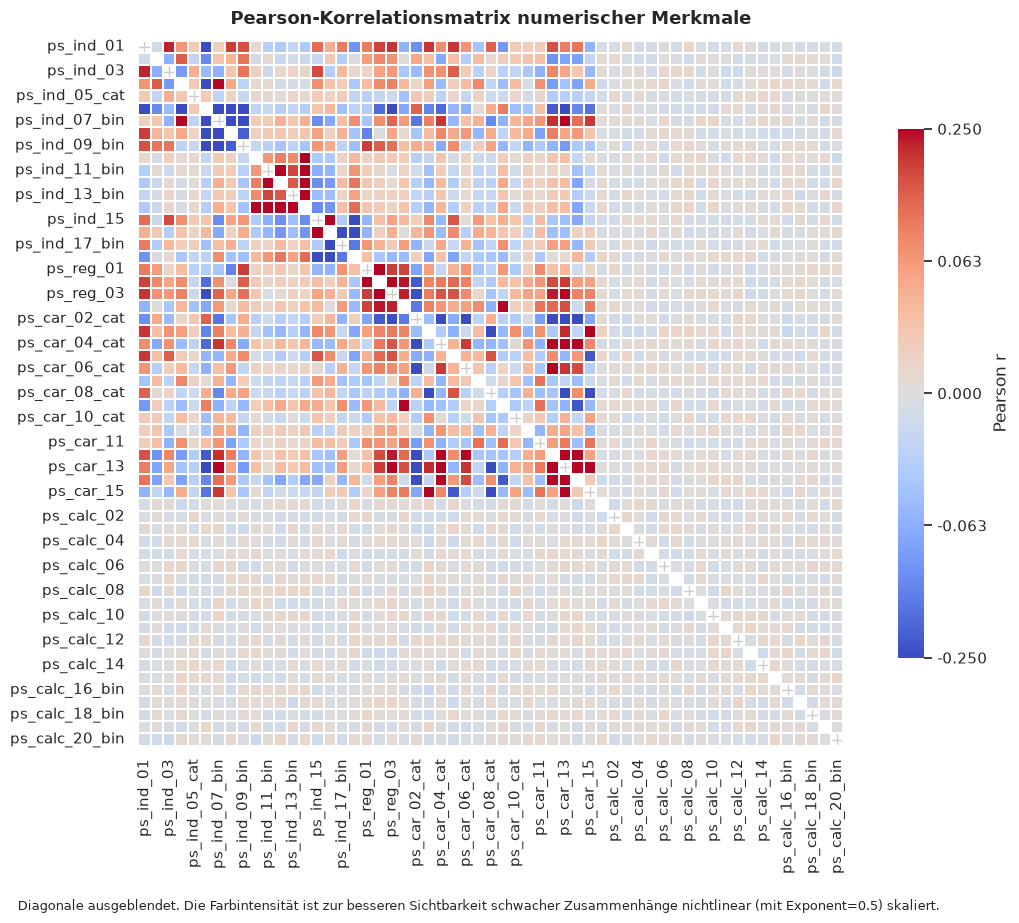

In [27]:
# Plot

# Diagonale ausblenden und dafür andere hervorheben
mask = np.eye(corr_matrix.shape[0], dtype=bool)

off_diagonal_values = corr_matrix.to_numpy()[~mask]
v_limit = np.nanpercentile(np.abs(off_diagonal_values), 97.5)

if v_limit == 0:
    v_limit = 0.05

# Stärkerer Kontrast für schwache Ausprägungen
exponent = 0.5
corr_display = np.sign(corr_matrix) * (np.abs(corr_matrix) ** exponent)
v_limit_display = v_limit ** exponent

# Labels bezeichnen mit Pearsons-r-Werten
tick_positions = np.linspace(
    -v_limit_display,
    v_limit_display,
    5,
)
tick_labels = np.sign(tick_positions) * (
    np.abs(tick_positions) ** (1 / exponent)
)

fig, ax = plt.subplots(figsize=(12, 9))

# Als Heatmap ausgeben lassen
heatmap = sns.heatmap(
    corr_display,
    cmap="coolwarm",
    center=0,
    vmin=-v_limit_display,
    vmax=v_limit_display,
    mask=mask,
    square=True,
    linewidths=0.25,
    cbar_kws={
        "shrink": 0.75,
        "ticks": tick_positions,
        "label": "Pearson r",
    },
    ax=ax,
)

cbar = heatmap.collections[0].colorbar
cbar.set_ticklabels(
    [f"{value:.3f}" for value in tick_labels]
)

ax.set_title(
    "Pearson-Korrelationsmatrix numerischer Merkmale",
    fontsize=13,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis="x", labelrotation=90)
ax.tick_params(axis="y", labelrotation=0)

fig.text(
    0.5,
    -0.02,
    (
        "Diagonale ausgeblendet. "
        "Die Farbintensität ist zur besseren Sichtbarkeit schwacher "
        "Zusammenhänge nichtlinear (mit Exponent=0.5) skaliert."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "03_numeric_correlation_matrix.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## 3. Zielvariable – univariate Beschreibung

In [29]:
# Kategorien für später definieren
categorical_features = feature_inventory.query(
    "role == 'categorical'"
).index.to_list()

binary_features = feature_inventory.query(
    "role == 'binary'"
).index.to_list()

numeric_features = feature_inventory.query(
    "role == 'numeric_or_ordinal'"
).index.to_list()

calculated_features = feature_inventory.query(
    "family == 'calculated'"
).index.to_list()

In [30]:
target_summary = (
    df[target_column]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
    .assign(
        proportion=lambda frame: (
            frame["count"]
            / frame["count"].sum()
        )
    )
)

target_summary

,count,proportion
target,,
0,573518,0.9636
1,21694,0.0364


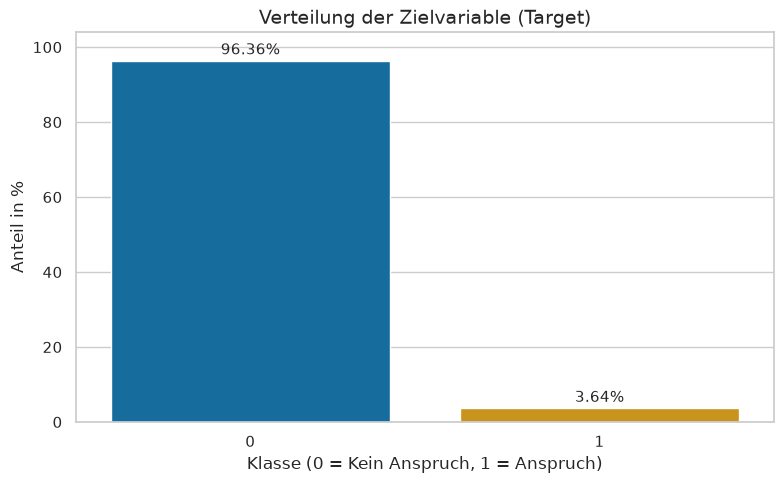

In [31]:
# Target-Verteilung als Balkendiagramm
fig, ax = plt.subplots(figsize=(8, 5))

# Prozentuale Verteilung berechnen
target_counts = df['target'].value_counts(normalize=True) * 100

sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, 
            hue=target_counts.index, palette=['#0072B2', '#E69F00'], legend=False)

ax.set_title('Verteilung der Zielvariable (Target)', fontsize=14)
ax.set_xlabel('Klasse (0 = Kein Anspruch, 1 = Anspruch)', fontsize=12)
ax.set_ylabel('Anteil in %', fontsize=12)

ax.set_ylim(0, 104)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=2, fontsize=11)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_target_distribution.pdf", format='pdf', bbox_inches='tight')
plt.show()

## 4. Missing Values auf dem vollständigen Datensatz

In [32]:
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_rate": df.isna().mean(),
            "non_missing_count": df.notna().sum(),
        }
    )
    .loc[lambda frame: frame["missing_count"] > 0]
    .sort_values(
        "missing_rate",
        ascending=False,
    )
)

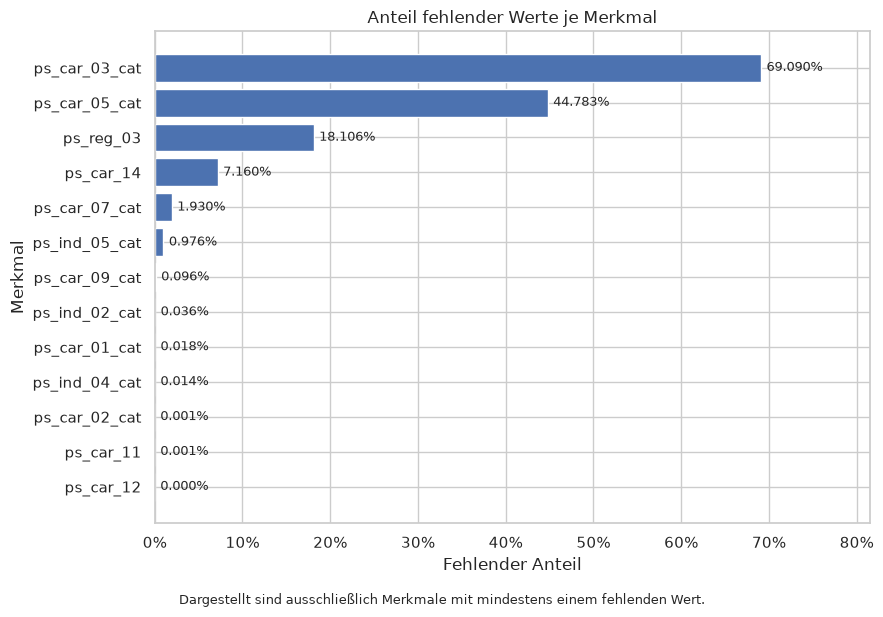

In [34]:
## Missingness als Plot mit Prozentangaben
import matplotlib.ticker as mtick

missing_plot = (
    missing_summary
    .reset_index(names="feature")
    .sort_values("missing_rate")
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    missing_plot["feature"],
    missing_plot["missing_rate"],
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.3%}"
        for value in missing_plot["missing_rate"]
    ],
    padding=4,
    fontsize=9,
)

ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0)
)

ax.set(
    title="Anteil fehlender Werte je Merkmal",
    xlabel="Fehlender Anteil",
    ylabel="Merkmal",
)

ax.set_xlim(
    0,
    missing_plot["missing_rate"].max() * 1.18,
)

fig.text(
    0.5,
    -0.02,
    (
        "Dargestellt sind ausschließlich Merkmale mit mindestens einem "
        "fehlenden Wert."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "missing_rates.pdf",
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_DIR / "missing_rates.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

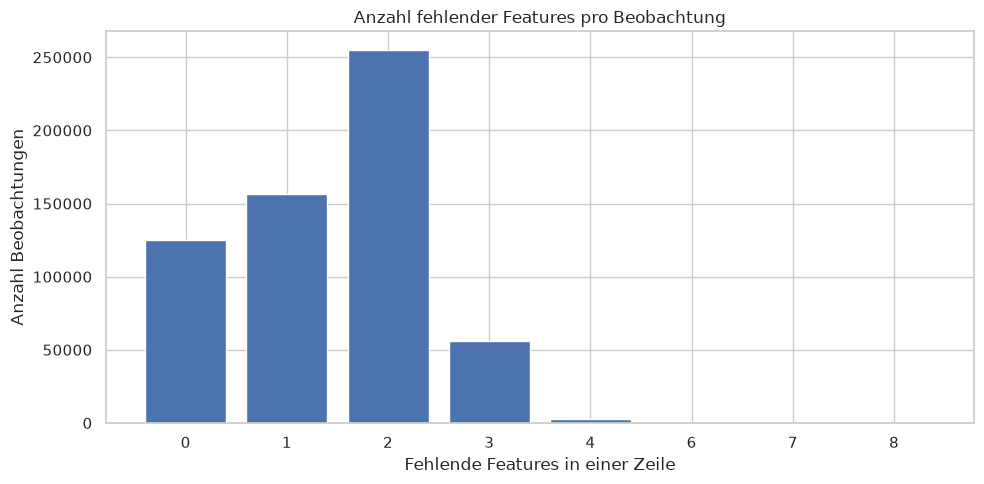

In [35]:
## Missing Values pro Zeile als Plot

missing_per_row = (
    df[feature_columns]
    .isna()
    .sum(axis="columns")
)

missing_per_row_distribution = (
    missing_per_row
    .value_counts()
    .sort_index()
    .rename_axis("missing_features")
    .rename("rows")
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    missing_per_row_distribution.index.astype(str),
    missing_per_row_distribution.values,
)

ax.set(
    title="Anzahl fehlender Features pro Beobachtung",
    xlabel="Fehlende Features in einer Zeile",
    ylabel="Anzahl Beobachtungen",
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "missing_features_per_row.pdf",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

In [36]:
## Verteilung fehlender Werte entlang der Zeilenreihenfolge

feature_cols = df.columns.drop("target")

X_missing = df[feature_cols].isna().astype(int)

y_adversarial = np.zeros(len(df), dtype=int)
y_adversarial[len(df) // 2:] = 1

clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
)

auc_scores = cross_val_score(
    clf,
    X_missing,
    y_adversarial,
    cv=5,
    scoring="roc_auc",
)

print(f"Mittlere AUC-ROC: {auc_scores.mean():.4f}")
print(f"Standardabweichung: {auc_scores.std():.4f}")

Mittlere AUC-ROC: 0.5000
Standardabweichung: 0.0005


## 5. Univariate Verteilungen der Features

In [37]:
role_labels_de = {
    "binary": "binär",
    "categorical": "kategorial",
    "numeric_or_ordinal": "numerisch/ordinal",
}

feature_summary_base = feature_inventory.copy()

feature_summary_base["Merkmalstyp"] = (
    feature_summary_base["role"]
    .map(role_labels_de)
)

feature_summary_base["dominant_share"] = [
    df[column]
    .value_counts(normalize=True, dropna=False)
    .iloc[0]
    for column in feature_summary_base.index
]

In [38]:
feature_type_summary = (
    feature_summary_base
    .groupby("Merkmalstyp", observed=True)
    .agg(
        **{
            "Anzahl Merkmale": ("role", "size"),
            "Median eindeutige Werte": ("non_missing_unique", "median"),
            "Max. eindeutige Werte": ("non_missing_unique", "max"),
            "Merkmale mit Missing Values": (
                "missing_count",
                lambda values: (values > 0).sum(),
            ),
            "Max. fehlender Anteil (%)": (
                "missing_rate",
                lambda values: values.max() * 100,
            ),
            "Median Anteil häufigster Wert (%)": (
                "dominant_share",
                lambda values: values.median() * 100,
            ),
            "Nahezu konstante Merkmale (>95 %)": (
                "dominant_share",
                lambda values: (values > 0.95).sum(),
            ),
        }
    )
    .round(2)
)

In [39]:
feature_type_summary.round(2).to_csv(
    OUTPUT_DIR / "feature_type_summary.csv",
    encoding="utf-8",
)

feature_type_summary.style.format(
    {
        "Anzahl Merkmale": "{:.0f}",
        "Median eindeutige Werte": "{:.2f}",
        "Max. eindeutige Werte": "{:.0f}",
        "Merkmale mit Missing Values": "{:.0f}",
        "Max. fehlender Anteil (%)": "{:.2f}",
        "Median Anteil häufigster Wert (%)": "{:.2f}",
        "Nahezu konstante Merkmale (>95 %)": "{:.0f}",
    }
)

,Anzahl Merkmale,Median eindeutige Werte,Max. eindeutige Werte,Merkmale mit Missing Values,Max. fehlender Anteil (%),Median Anteil häufigster Wert (%),Nahezu konstante Merkmale (>95 %)
Merkmalstyp,,,,,,,
binär,17,2.00,2,0,0.00,83.61,4
kategorial,14,3.50,104,9,69.09,70.82,1
numerisch/ordinal,26,11.00,70416,4,18.11,21.36,1


In [40]:
noteworthy_features = (
    feature_summary_base
    .assign(
        auffaelligkeit=np.select(
            [
                feature_summary_base["missing_rate"] >= 0.10,
                feature_summary_base["dominant_share"] >= 0.95,
                feature_summary_base["non_missing_unique"] >= 50,
            ],
            [
                "hoher fehlender Anteil (≥10 %)",
                "stark dominierender Wert (≥95 %)",
                "hohe Kardinalität (≥50 Werte)",
            ],
            default="",
        )
    )
    .loc[lambda frame: frame["auffaelligkeit"] != ""]
    .reset_index()
    .rename(
        columns={
            "feature": "Merkmal",
            "non_missing_unique": "Eindeutige Werte",
            "missing_rate": "Fehlender Anteil",
            "dominant_share": "Anteil häufigster Wert",
            "auffaelligkeit": "Auffälligkeit",
        }
    )
    [
        [
            "Merkmal",
            "Merkmalstyp",
            "Eindeutige Werte",
            "Fehlender Anteil",
            "Anteil häufigster Wert",
            "Auffälligkeit",
        ]
    ]
    .sort_values(
        [
            "Auffälligkeit",
            "Fehlender Anteil",
            "Anteil häufigster Wert",
        ],
        ascending=[True, False, False],
    )
)

In [41]:
noteworthy_features[
    "Fehlender Anteil"
] = noteworthy_features[
    "Fehlender Anteil"
].map(lambda value: f"{value:.2%}")

noteworthy_features[
    "Anteil häufigster Wert"
] = noteworthy_features[
    "Anteil häufigster Wert"
].map(lambda value: f"{value:.2%}")


noteworthy_features.to_csv(
    OUTPUT_DIR / "noteworthy_features.csv",
    encoding="utf-8",
)

noteworthy_features

,Merkmal,Merkmalstyp,Eindeutige Werte,Fehlender Anteil,Anteil häufigster Wert,Auffälligkeit
10,ps_car_14,numerisch/ordinal,849,7.16%,7.16%,hohe Kardinalität (≥50 Werte)
8,ps_car_12,numerisch/ordinal,183,0.00%,28.66%,hohe Kardinalität (≥50 Werte)
7,ps_car_11_cat,kategorial,104,0.00%,14.29%,hohe Kardinalität (≥50 Werte)
9,ps_car_13,numerisch/ordinal,70416,0.00%,0.06%,hohe Kardinalität (≥50 Werte)
4,ps_car_03_cat,kategorial,2,69.09%,69.09%,hoher fehlender Anteil (≥10 %)
5,ps_car_05_cat,kategorial,2,44.78%,44.78%,hoher fehlender Anteil (≥10 %)
12,ps_reg_03,numerisch/ordinal,5012,18.11%,18.11%,hoher fehlender Anteil (≥10 %)
0,ps_ind_10_bin,binär,2,0.00%,99.96%,stark dominierender Wert (≥95 %)
3,ps_ind_13_bin,binär,2,0.00%,99.91%,stark dominierender Wert (≥95 %)
1,ps_ind_11_bin,binär,2,0.00%,99.83%,stark dominierender Wert (≥95 %)


In [42]:
feature_profile = (
    feature_summary_base
    .reset_index()
    .rename(columns={"feature": "Merkmal"})
)

feature_profile["Fehlender Anteil (%)"] = (
    feature_profile["missing_rate"] * 100
)

feature_profile["Anteil häufigster Wert (%)"] = (
    feature_profile["dominant_share"] * 100
)

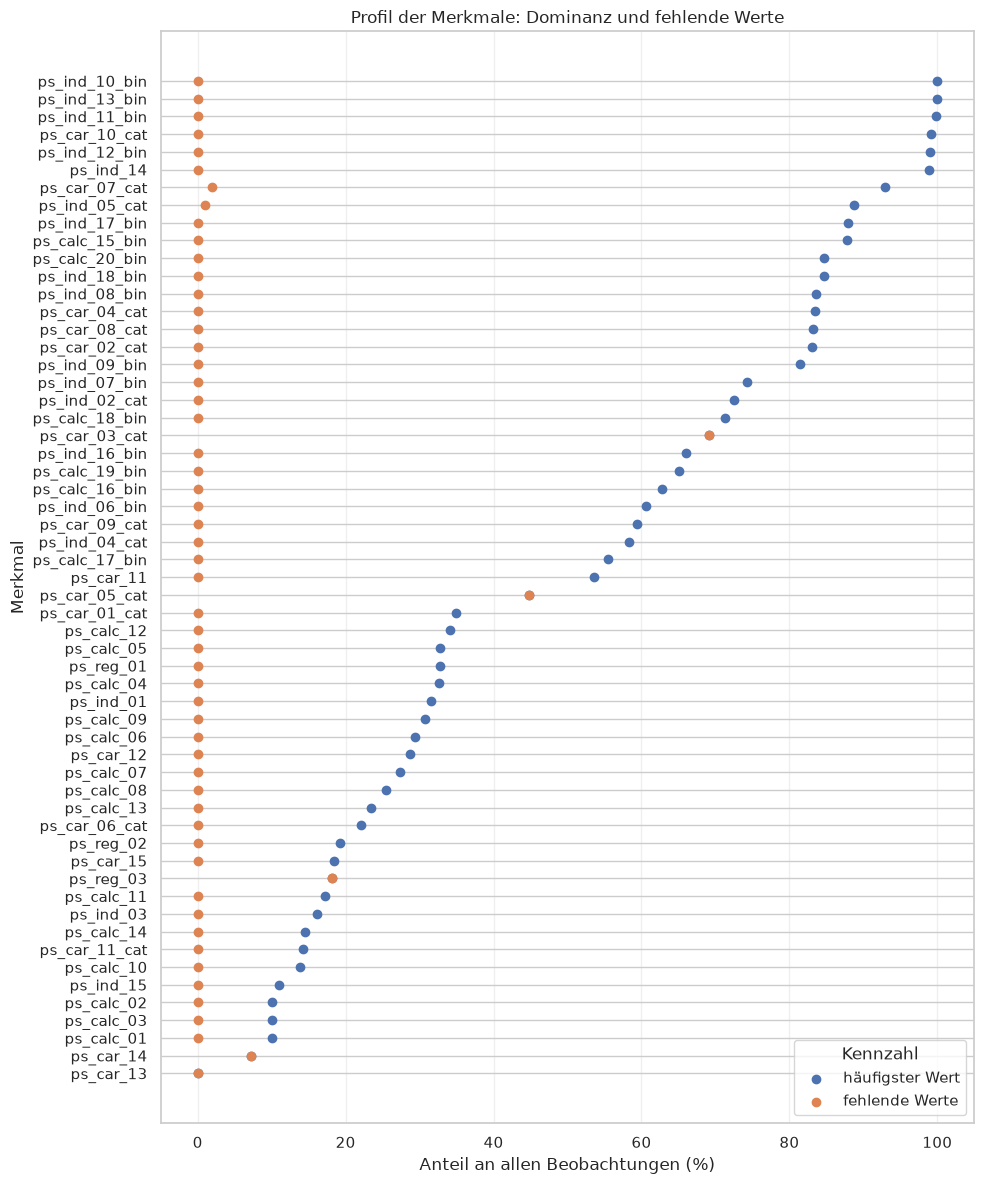

In [43]:
plot_data = (
    feature_profile
    .assign(
        Merkmal=lambda frame: pd.Categorical(
            frame["Merkmal"],
            categories=frame.sort_values(
                "Anteil häufigster Wert (%)",
                ascending=True,
            )["Merkmal"],
            ordered=True,
        )
    )
    .sort_values("Merkmal")
)

fig, ax = plt.subplots(figsize=(10, 12))

ax.scatter(
    plot_data["Anteil häufigster Wert (%)"],
    plot_data["Merkmal"],
    label="häufigster Wert",
)

ax.scatter(
    plot_data["Fehlender Anteil (%)"],
    plot_data["Merkmal"],
    label="fehlende Werte",
)

ax.set(
    title="Profil der Merkmale: Dominanz und fehlende Werte",
    xlabel="Anteil an allen Beobachtungen (%)",
    ylabel="Merkmal",
)

ax.legend(title="Kennzahl")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "feature_profile_plot.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## **Teil C - EDA nach dem Datensatzsplit**

## 1. Datensatzsplit prüfen und laden

In [46]:
TARGET = "target"

train_idx = np.load("train_idx.npy")
val_idx = np.load("val_idx.npy")
test_idx = np.load("test_idx.npy")

print("train_Index:", train_idx.shape, train_idx.dtype)
print("val_Index:", val_idx.shape, val_idx.dtype)
print("test_Index:", test_idx.shape, test_idx.dtype)

train_Index: (476168,) int64
val_Index: (59522,) int64
test_Index: (59522,) int64


In [45]:
train_df = df.iloc[train_idx].reset_index(drop=True)
validation_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (476168, 58)
Validation: (59522, 58)
Test: (59522, 58)


In [47]:
split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Zeilen": [
            len(train_df),
            len(validation_df),
            len(test_df),
        ],
        "Positive Fälle": [
            train_df[TARGET].sum(),
            validation_df[TARGET].sum(),
            test_df[TARGET].sum(),
        ],
        "Positivrate (%)": [
            train_df[TARGET].mean() * 100,
            validation_df[TARGET].mean() * 100,
            test_df[TARGET].mean() * 100,
        ],
    }
)

split_summary

,Split,Zeilen,Positive Fälle,Positivrate (%)
0,Train,476168,17356,3.6449
1,Validation,59522,2169,3.6440
2,Test,59522,2169,3.6440


## 2. Zusammenhang fehlende Werte mit dem Target

In [49]:
train_analysis = train_df.copy()

feature_cols = [
    col
    for col in train_analysis.columns
    if col != "target"
]

train_analysis["missing_count"] = (
    train_analysis[feature_cols]
    .isna()
    .sum(axis=1)
)

train_analysis["missing_count_grouped"] = (
    train_analysis["missing_count"]
    .where(train_analysis["missing_count"] <= 4, "≥5")
)

missing_target_stats = (
    train_analysis
    .groupby("missing_count_grouped", observed=True)["target"]
    .agg(
        Anzahl="count",
        Schadensquote="mean",
    )
    .reset_index()
)

missing_target_stats["Schadensquote (%)"] = (
    missing_target_stats["Schadensquote"] * 100
)

missing_target_stats

,missing_count_grouped,Anzahl,Schadensquote,Schadensquote (%)
0,0,100002,0.0452,4.5249
1,1,125089,0.0364,3.6358
2,2,203813,0.0340,3.4041
3,3,44904,0.0284,2.8416
4,4,2302,0.0209,2.0851
5,≥5,58,0.3621,36.2069


In [53]:
kategorie_reihenfolge = ["0", "1", "2", "3", "4", "≥5"]
missing_target_stats["missing_count_grouped"] = pd.Categorical(
    missing_target_stats["missing_count_grouped"].astype(str),
    categories=kategorie_reihenfolge,
    ordered=True
)


missing_target_stats = missing_target_stats.sort_values("missing_count_grouped").reset_index(drop=True)

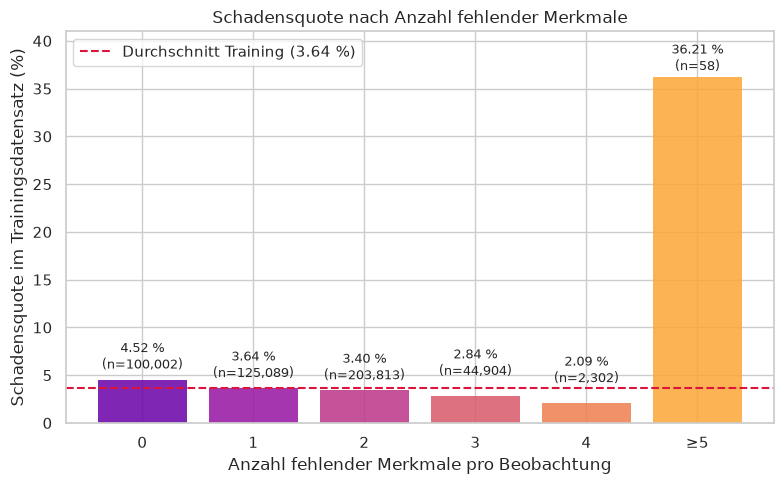

In [54]:
# Bar Plot

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(context="notebook", style="whitegrid")

# Farbpalette
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(missing_target_stats)))

bars = ax.bar(
    missing_target_stats["missing_count_grouped"].astype(str),
    missing_target_stats["Schadensquote (%)"],
    color=colors,
    edgecolor="none",
    alpha=0.85,
)

global_mean = train_analysis["target"].mean() * 100

ax.axhline(
    global_mean,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Durchschnitt Training ({global_mean:.2f} %)",
)

# Individuelle Label-Setzung
for i, bar in enumerate(bars):
    height = bar.get_height()
    x_val = missing_target_stats["missing_count_grouped"].iloc[i]
    count = missing_target_stats["Anzahl"].iloc[i]
    
    label_text = f"{height:.2f} %\n(n={count:,})"

    if x_val == "3" or x_val == "4":
        current_padding = 12 
    elif x_val == "≥5":
        current_padding = 2
    else:
        current_padding = 5
        
    ax.annotate(
        label_text,
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, current_padding),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Achsenskalierung
ax.set(
    title="Schadensquote nach Anzahl fehlender Merkmale",
    xlabel="Anzahl fehlender Merkmale pro Beobachtung",
    ylabel="Schadensquote im Trainingsdatensatz (%)",
)
ax.set_ylim(0, 41)

ax.legend()
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "missingness_claim_rate_train.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [56]:
# Top-5-Merkmale mit höchstem Fehlwertanteil im Trainingsdatensatz
feature_cols = [
    col
    for col in train_df.columns
    if col != "target"
]

top_5_features = (
    train_df[feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
    .to_list()
)

In [57]:
missing_by_target = []

for feature in top_5_features:
    missing_by_target.append(
        {
            "Merkmal": feature,
            "Gruppe": "gesamt",
            "Fehlender Anteil (%)": train_df[feature].isna().mean() * 100,
        }
    )

    for target_value, label in [
        (0, "target = 0"),
        (1, "target = 1"),
    ]:
        subset = train_df.loc[
            train_df["target"] == target_value,
            feature,
        ]

        missing_by_target.append(
            {
                "Merkmal": feature,
                "Gruppe": label,
                "Fehlender Anteil (%)": subset.isna().mean() * 100,
            }
        )

missing_by_target = pd.DataFrame(missing_by_target)

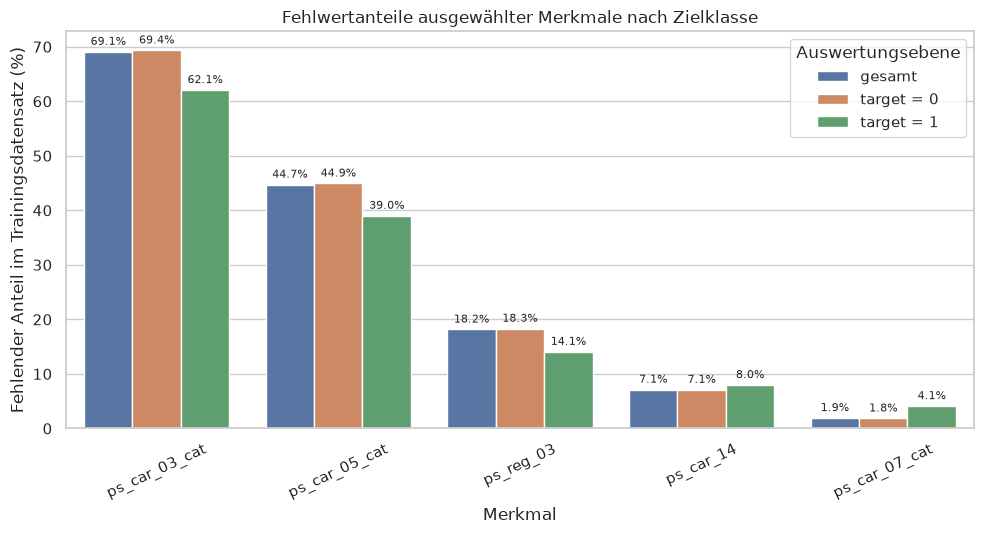

In [58]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.barplot(
    data=missing_by_target,
    x="Merkmal",
    y="Fehlender Anteil (%)",
    hue="Gruppe",
    ax=ax,
)

# Zahlen auf die Balken schreiben
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=8,
    )

ax.set(
    title="Fehlwertanteile ausgewählter Merkmale nach Zielklasse",
    xlabel="Merkmal",
    ylabel="Fehlender Anteil im Trainingsdatensatz (%)",
)

ax.tick_params(axis="x", labelrotation=25)
ax.legend(title="Auswertungsebene")

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "missing_rates_by_target_train.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [59]:
# Tabelle
missing_target_rows = []

for feature in top_5_features:
    missing_mask = train_df[feature].isna()
    present_mask = ~missing_mask

    missing_target_rows.append(
        {
            "Merkmal": feature,
            "Anzahl fehlend": missing_mask.sum(),
            "Schäden bei fehlend": train_df.loc[missing_mask, "target"].sum(),
            "Schadensquote bei fehlend (%)": (
                train_df.loc[missing_mask, "target"].mean() * 100
            ),
            "Anzahl vorhanden": present_mask.sum(),
            "Schäden bei vorhanden": train_df.loc[present_mask, "target"].sum(),
            "Schadensquote bei vorhanden (%)": (
                train_df.loc[present_mask, "target"].mean() * 100
            ),
        }
    )

missing_target_table = pd.DataFrame(missing_target_rows)

missing_target_table["Differenz fehlend - vorhanden (Prozentpunkte)"] = (
    missing_target_table["Schadensquote bei fehlend (%)"]
    - missing_target_table["Schadensquote bei vorhanden (%)"]
)

missing_target_table.round(2)

,Merkmal,Anzahl fehlend,Schäden bei fehlend,Schadensquote bei fehlend (%),Anzahl vorhanden,Schäden bei vorhanden,Schadensquote bei vorhanden (%),Differenz fehlend - vorhanden (Prozentpunkte)
0,ps_car_03_cat,328998,10774,3.2700,147170,6582,4.4700,-1.2000
1,ps_car_05_cat,212985,6773,3.1800,263183,10583,4.0200,-0.8400
2,ps_reg_03,86462,2442,2.8200,389706,14914,3.8300,-1.0000
3,ps_car_14,34003,1386,4.0800,442165,15970,3.6100,0.4600
4,ps_car_07_cat,9192,715,7.7800,466976,16641,3.5600,4.2100


In [60]:
missing_target_table = (
    missing_by_target
    .pivot(
        index="Merkmal",
        columns="Gruppe",
        values="Fehlender Anteil (%)",
    )
    .assign(
        **{
            "Differenz target=1 - target=0": lambda frame: (
                frame["target = 1"] - frame["target = 0"]
            )
        }
    )
    .round(2)
)

missing_target_table

Gruppe,gesamt,target = 0,target = 1,Differenz target=1 - target=0
Merkmal,,,,
ps_car_03_cat,69.0900,69.3600,62.0800,-7.2800
ps_car_05_cat,44.7300,44.9400,39.0200,-5.9200
ps_car_07_cat,1.9300,1.8500,4.1200,2.2700
ps_car_14,7.1400,7.1100,7.9900,0.8800
ps_reg_03,18.1600,18.3100,14.0700,-4.2400


## 3. Hinweis auf potenziell künstliche oder transformierte Daten 

Nach [Benfords Law](https://towardsdatascience.com/anomaly-detection-using-benfords-law-253eaa25e6c5/) ist die erste Zahl in numerischen realen Daten häufig 1, das kann man ausnutzen um potenziell synthetische Daten oder Transformationen zu entdecken.

In [65]:
BENFORD_EXPECTED = pd.Series(
    {
        digit: np.log10(1 + 1 / digit)
        for digit in range(1, 10)
    },
    name="Benford erwartet",
)

numeric_cols = (
    train_df
    .select_dtypes(include="number")
    .columns
    .drop("target", errors="ignore")
    .to_list()
)

In [66]:
def first_significant_digits(series: pd.Series) -> pd.Series:
    values = (
        pd.to_numeric(series, errors="coerce")
        .dropna()
        .astype(float)
    )

    values = values[np.isfinite(values)]
    values = values[values != 0].abs()

    if values.empty:
        return pd.Series(dtype="int64")

    magnitudes = 10 ** np.floor(np.log10(values))
    digits = np.floor(values / magnitudes).astype(int)

    return pd.Series(digits).loc[lambda s: s.between(1, 9)]

In [67]:
def benford_metrics(series: pd.Series) -> dict:
    values = (
        pd.to_numeric(series, errors="coerce")
        .dropna()
        .astype(float)
    )

    positive_values = values[
        np.isfinite(values) & (values > 0)
    ]

    digits = first_significant_digits(series)

    if digits.empty:
        observed = pd.Series(0.0, index=range(1, 10))
    else:
        observed = (
            digits
            .value_counts(normalize=True)
            .reindex(range(1, 10), fill_value=0.0)
            .sort_index()
        )

    abs_deviation = (observed - BENFORD_EXPECTED).abs()

    if positive_values.empty:
        order_span = np.nan
    else:
        order_span = (
            np.log10(positive_values.max())
            - np.log10(positive_values.min())
        )

    return {
        "n_nichtfehlend": values.size,
        "n_positiv": positive_values.size,
        "eindeutige_werte": values.nunique(),
        "minimum_positiv": positive_values.min() if not positive_values.empty else np.nan,
        "maximum_positiv": positive_values.max() if not positive_values.empty else np.nan,
        "zehnerpotenzen_spannweite": order_span,
        "benford_mad_pp": abs_deviation.mean() * 100,
        "benford_max_abw_pp": abs_deviation.max() * 100,
    }

In [68]:
benford_screening = (
    pd.DataFrame(
        {
            column: benford_metrics(train_df[column])
            for column in numeric_cols
        }
    )
    .T
    .reset_index(names="Merkmal")
)

benford_screening["Benford-Eignung"] = np.select(
    [
        (
            (benford_screening["n_positiv"] >= 1_000)
            & (benford_screening["eindeutige_werte"] >= 50)
            & (benford_screening["zehnerpotenzen_spannweite"] >= 1)
        ),
        (
            (benford_screening["n_positiv"] >= 1_000)
            & (benford_screening["eindeutige_werte"] >= 20)
        ),
    ],
    [
        "vergleichsweise geeignet",
        "eingeschränkt geeignet",
    ],
    default="kaum geeignet",
)

benford_screening = (
    benford_screening
    .sort_values(
        [
            "Benford-Eignung",
            "benford_mad_pp",
        ],
        ascending=[True, False],
    )
)

benford_screening.round(4).to_csv(
    OUTPUT_DIR / "benford_screening_train.csv",
    index=False,
    encoding="utf-8",
)

benford_screening.round(4)

,Merkmal,n_nichtfehlend,n_positiv,eindeutige_werte,minimum_positiv,maximum_positiv,zehnerpotenzen_spannweite,benford_mad_pp,benford_max_abw_pp,Benford-Eignung
35,ps_car_14,"442,165.0000","442,165.0000",838.0000,0.1095,0.6364,0.7641,15.8943,59.7592,eingeschränkt geeignet
47,ps_calc_11,"476,168.0000","474,204.0000",20.0000,1.0000,19.0000,1.2788,7.6798,22.6216,eingeschränkt geeignet
50,ps_calc_14,"476,168.0000","475,930.0000",23.0000,1.0000,22.0000,1.3424,7.5883,16.1003,eingeschränkt geeignet
46,ps_calc_10,"476,168.0000","476,058.0000",25.0000,1.0000,25.0000,1.3979,7.1986,16.8019,eingeschränkt geeignet
29,ps_car_09_cat,"475,725.0000","319,959.0000",5.0000,1.0000,4.0000,0.6021,15.7185,70.7334,kaum geeignet
3,ps_ind_04_cat,"476,107.0000","198,659.0000",2.0000,1.0000,1.0000,0.0000,15.5327,69.8970,kaum geeignet
5,ps_ind_06_bin,"476,168.0000","187,397.0000",2.0000,1.0000,1.0000,0.0000,15.5327,69.8970,kaum geeignet
6,ps_ind_07_bin,"476,168.0000","122,347.0000",2.0000,1.0000,1.0000,0.0000,15.5327,69.8970,kaum geeignet
7,ps_ind_08_bin,"476,168.0000","78,187.0000",2.0000,1.0000,1.0000,0.0000,15.5327,69.8970,kaum geeignet
8,ps_ind_09_bin,"476,168.0000","88,237.0000",2.0000,1.0000,1.0000,0.0000,15.5327,69.8970,kaum geeignet


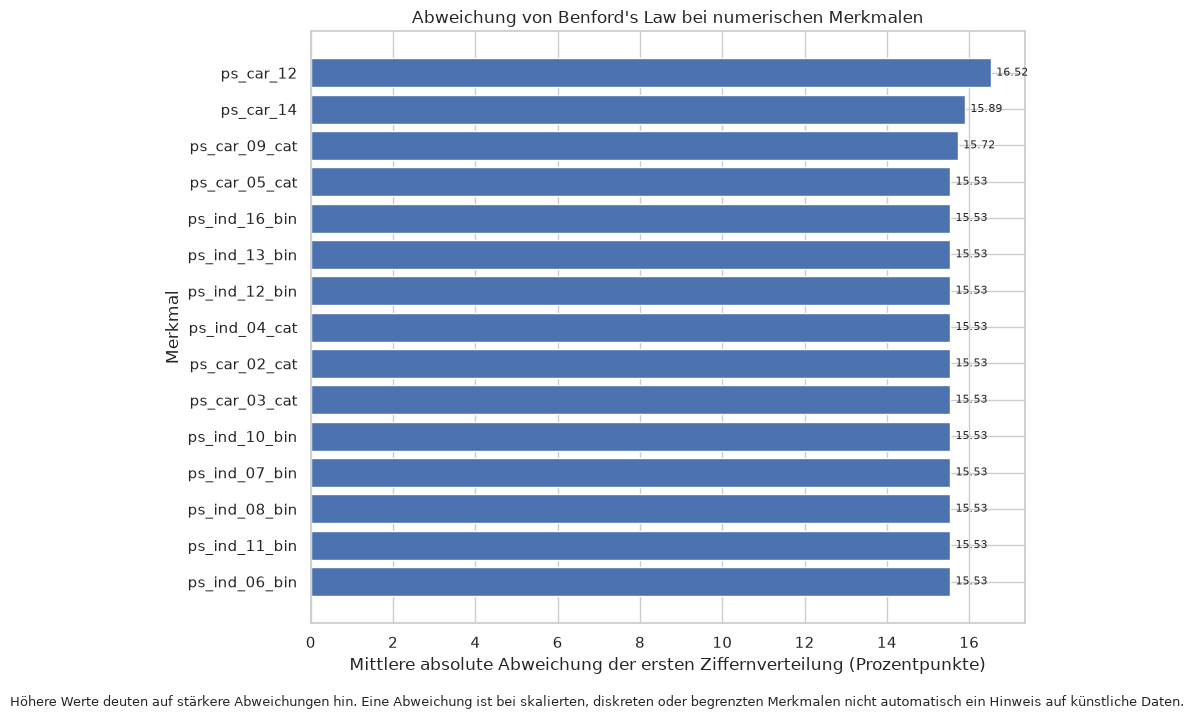

In [71]:
# Plot 

plot_data = (
    benford_screening
    .sort_values("benford_mad_pp", ascending=False)
    .head(15)
    .sort_values("benford_mad_pp")
)

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    plot_data["Merkmal"],
    plot_data["benford_mad_pp"],
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in plot_data["benford_mad_pp"]
    ],
    padding=4,
    fontsize=8,
)

ax.set(
    title="Abweichung von Benford's Law bei numerischen Merkmalen",
    xlabel="Mittlere absolute Abweichung der ersten Ziffernverteilung (Prozentpunkte)",
    ylabel="Merkmal",
)

fig.text(
    0.5,
    -0.02,
    (
        "Höhere Werte deuten auf stärkere Abweichungen hin. "
        "Eine Abweichung ist bei skalierten, diskreten oder begrenzten "
        "Merkmalen nicht automatisch ein Hinweis auf künstliche Daten."
    ),
    ha="center",
    fontsize=9,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "benford_deviation_screening_train.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

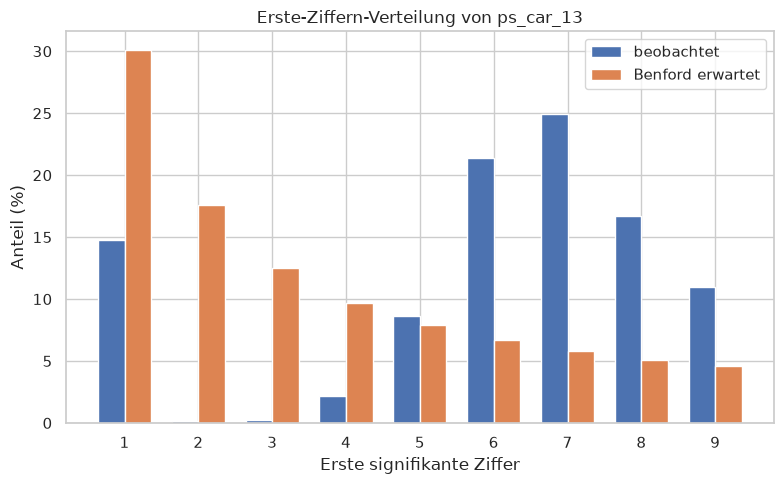

In [72]:
# Plot für ps_car_13

feature = "ps_car_13"

observed_digits = (
    first_significant_digits(train_df[feature])
    .value_counts(normalize=True)
    .reindex(range(1, 10), fill_value=0.0)
    .sort_index()
)

benford_detail = (
    pd.DataFrame(
        {
            "Erste Ziffer": range(1, 10),
            "Beobachtet (%)": observed_digits.values * 100,
            "Benford erwartet (%)": BENFORD_EXPECTED.values * 100,
        }
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    benford_detail["Erste Ziffer"] - 0.18,
    benford_detail["Beobachtet (%)"],
    width=0.36,
    label="beobachtet",
)

ax.bar(
    benford_detail["Erste Ziffer"] + 0.18,
    benford_detail["Benford erwartet (%)"],
    width=0.36,
    label="Benford erwartet",
)

ax.set(
    title=f"Erste-Ziffern-Verteilung von {feature}",
    xlabel="Erste signifikante Ziffer",
    ylabel="Anteil (%)",
)

ax.set_xticks(range(1, 10))
ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / f"benford_detail_{feature}.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## 4. Suche nach künstlichen Transformationen

In [73]:
def as_numeric_array(series):
    values = (
        pd.to_numeric(series, errors="coerce")
        .dropna()
        .astype(float)
        .to_numpy()
    )
    return values[np.isfinite(values)]


def transformation_candidates(values):
    candidates = {}

    candidates["Originalwert"] = values

    candidates["Quadrat"] = values**2
    candidates["Kubik"] = values**3

    non_negative = values[values >= 0]
    positive = values[values > 0]
    greater_minus_one = values[values > -1]

    if len(non_negative) > 0:
        candidates["Wurzel"] = np.sqrt(non_negative)

    if len(positive) > 0:
        candidates["Logarithmus"] = np.log(positive)
        candidates["Kehrwert"] = 1 / positive

    if len(greater_minus_one) > 0:
        candidates["log1p"] = np.log1p(greater_minus_one)

    return candidates

In [74]:
def best_raster_result(series):
    values = as_numeric_array(series)

    if len(values) == 0:
        return None

    scales = [1, 2, 4, 5, 10, 20, 25, 50, 100, 1_000, 10_000]
    tolerance = 1e-6

    results = []

    for transformation, transformed_values in transformation_candidates(values).items():
        if len(transformed_values) == 0:
            continue

        for scale in scales:
            scaled = transformed_values * scale
            distance = np.abs(scaled - np.round(scaled))

            results.append(
                {
                    "Darstellung": transformation,
                    "Skalierungsfaktor": scale,
                    "Anteil auf Raster": (distance <= tolerance).mean(),
                    "Median Abstand zum Raster": np.median(distance),
                }
            )

    return (
        pd.DataFrame(results)
        .sort_values(
            ["Anteil auf Raster", "Median Abstand zum Raster"],
            ascending=[False, True],
        )
        .iloc[0]
        .to_dict()
    )

In [75]:
extended_grid_screening = []

for feature in numeric_cols:
    result = best_raster_result(train_df[feature])
    values = as_numeric_array(train_df[feature])

    extended_grid_screening.append(
        {
            "Merkmal": feature,
            "Darstellung": result["Darstellung"],
            "Skalierungsfaktor": result["Skalierungsfaktor"],
            "Anteil auf Raster (%)": result["Anteil auf Raster"] * 100,
            "Median Abstand zum Raster": result["Median Abstand zum Raster"],
            "Eindeutige Werte": pd.Series(values).nunique(),
            "Min": np.min(values),
            "Max": np.max(values),
        }
    )

extended_grid_screening = (
    pd.DataFrame(extended_grid_screening)
    .sort_values(
        ["Anteil auf Raster (%)", "Eindeutige Werte"],
        ascending=[False, True],
    )
)

extended_grid_screening.round(6)

,Merkmal,Darstellung,Skalierungsfaktor,Anteil auf Raster (%),Median Abstand zum Raster,Eindeutige Werte,Min,Max
3,ps_ind_04_cat,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
5,ps_ind_06_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
6,ps_ind_07_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
7,ps_ind_08_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
8,ps_ind_09_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
9,ps_ind_10_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
10,ps_ind_11_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
11,ps_ind_12_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
12,ps_ind_13_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000
15,ps_ind_16_bin,Originalwert,1,100.0000,0.0000,2,0.0000,1.0000


In [77]:
def classify_screening_row(row):
    representation = row["Darstellung"]
    scale = int(row["Skalierungsfaktor"])
    raster_share = row["Anteil auf Raster (%)"]
    unique_values = row["Eindeutige Werte"]

    if raster_share < 99.9:
        return "kein starker Rasterbefund"

    if representation != "Originalwert":
        return "Transformationskandidat"

    if scale == 1 and unique_values <= 30:
        return "diskret/ordinal"

    if scale > 1:
        return "gerundet/skaliert"

    return "Originalraster"

In [78]:
extended_grid_screening["Befundklasse"] = (
    extended_grid_screening.apply(
        classify_screening_row,
        axis=1,
    )
)

In [79]:
compact_grid_summary = (
    extended_grid_screening
    .groupby("Befundklasse", observed=True)
    .agg(
        **{
            "Anzahl Merkmale": ("Merkmal", "count"),
            "Beispielmerkmale": (
                "Merkmal",
                lambda values: ", ".join(values.head(8)),
            ),
            "Median eindeutige Werte": ("Eindeutige Werte", "median"),
            "Max. Rasteranteil (%)": ("Anteil auf Raster (%)", "max"),
        }
    )
    .reset_index()
    .round(2)
)

In [76]:
compact_grid_summary.round(2).to_csv(
    OUTPUT_DIR / "global_grid_screening_exp4.csv",
    index=False,
    encoding="utf-8",
)

compact_grid_summary

,Befundklasse,Anzahl Merkmale,Beispielmerkmale,Median eindeutige Werte,Max. Rasteranteil (%)
0,Originalraster,1,ps_car_11_cat,104.0000,100.0000
1,Transformationskandidat,1,ps_car_15,15.0000,100.0000
2,diskret/ordinal,46,"ps_ind_04_cat, ps_ind_06_bin, ps_ind_07_bin, p...",2.5000,100.0000
3,gerundet/skaliert,5,"ps_reg_01, ps_calc_01, ps_calc_02, ps_calc_03,...",10.0000,100.0000
4,kein starker Rasterbefund,4,"ps_car_12, ps_car_14, ps_reg_03, ps_car_13","2,907.0000",84.3300


In [ ]:
calc_features = [
    col
    for col in train_df.columns
    if col.startswith("ps_calc_")
]

calc_profile_rows = []

In [88]:
for feature in calc_features:
    values = (
        pd.to_numeric(train_df[feature], errors="coerce")
        .dropna()
        .astype(float)
    )

    unique_values = np.sort(values.unique())

    if len(unique_values) > 1:
        steps = np.diff(unique_values)
        min_step = steps.min()
    else:
        min_step = np.nan

    value_distribution = values.value_counts(normalize=True)

    entropy = -np.sum(
        value_distribution * np.log(value_distribution)
    )

    max_entropy = np.log(len(value_distribution))

    normalized_entropy = (
        entropy / max_entropy
        if max_entropy > 0
        else np.nan
    )

    calc_profile_rows.append(
        {
            "Merkmal": feature,
            "Eindeutige Werte": len(unique_values),
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Kleinste Schrittweite": min_step,
            "Ganzzahlig": np.allclose(values, np.round(values)),
            "Auf 0,1-Raster": np.allclose(values * 10, np.round(values * 10)),
            "Anteil häufigster Wert (%)": value_distribution.iloc[0] * 100,
            "Normierte Entropie": normalized_entropy,
        }
    )

In [89]:
calc_profile = (
    pd.DataFrame(calc_profile_rows)
    .sort_values("Merkmal")
    .round(4)
)

calc_profile.to_csv(
    OUTPUT_DIR / "calc_feature_profile_train.csv",
    index=False,
    encoding="utf-8",
)

calc_profile

,Merkmal,Eindeutige Werte,Minimum,Maximum,Kleinste Schrittweite,Ganzzahlig,"Auf 0,1-Raster",Anteil häufigster Wert (%),Normierte Entropie
0,ps_calc_01,10,0.0000,0.9000,0.1000,False,True,10.0809,1.0000
20,ps_calc_01,10,0.0000,0.9000,0.1000,False,True,10.0809,1.0000
40,ps_calc_01,10,0.0000,0.9000,0.1000,False,True,10.0809,1.0000
1,ps_calc_02,10,0.0000,0.9000,0.1000,False,True,10.0849,1.0000
21,ps_calc_02,10,0.0000,0.9000,0.1000,False,True,10.0849,1.0000
41,ps_calc_02,10,0.0000,0.9000,0.1000,False,True,10.0849,1.0000
2,ps_calc_03,10,0.0000,0.9000,0.1000,False,True,10.1076,1.0000
22,ps_calc_03,10,0.0000,0.9000,0.1000,False,True,10.1076,1.0000
42,ps_calc_03,10,0.0000,0.9000,0.1000,False,True,10.1076,1.0000
3,ps_calc_04,6,0.0000,5.0000,1.0000,True,True,32.5940,0.8496


In [90]:
def all_raster_results_for_feature(series, feature_name):
    values = as_numeric_array(series)
    scales = [1, 2, 4, 5, 10, 20, 25, 50, 100, 1_000, 10_000]
    tolerance = 1e-6

    rows = []

    for representation, transformed_values in transformation_candidates(values).items():
        if len(transformed_values) == 0:
            continue

        for scale in scales:
            scaled = transformed_values * scale
            distance = np.abs(scaled - np.round(scaled))

            rows.append(
                {
                    "Merkmal": feature_name,
                    "Darstellung": representation,
                    "Skalierungsfaktor": scale,
                    "Anteil auf Raster (%)": (distance <= tolerance).mean() * 100,
                    "Median Abstand zum Raster": np.median(distance),
                    "Eindeutige Werte": pd.Series(values).nunique(),
                }
            )

    return pd.DataFrame(rows)

In [91]:
all_raster_results = pd.concat(
    [
        all_raster_results_for_feature(train_df[feature], feature)
        for feature in numeric_cols
    ],
    ignore_index=True,
)

top_raster_results = (
    all_raster_results
    .sort_values(
        [
            "Merkmal",
            "Anteil auf Raster (%)",
            "Median Abstand zum Raster",
        ],
        ascending=[True, False, True],
    )
    .groupby("Merkmal", observed=True)
    .head(5)
)

top_raster_results.round(6)

,Merkmal,Darstellung,Skalierungsfaktor,Anteil auf Raster (%),Median Abstand zum Raster,Eindeutige Werte
2853,ps_calc_01,Originalwert,10,100.0000,0.0000,10
2854,ps_calc_01,Originalwert,20,100.0000,0.0000,10
2856,ps_calc_01,Originalwert,50,80.0094,0.0000,10
2868,ps_calc_01,Quadrat,100,59.9246,0.0000,10
2906,ps_calc_01,Kehrwert,4,55.5610,0.0000,10
...,...,...,...,...,...,...
1559,ps_reg_03,Quadrat,100,1.3133,0.2500,4976
1558,ps_reg_03,Quadrat,50,1.3133,0.2500,4976
1557,ps_reg_03,Quadrat,25,1.0436,0.2500,4976
1556,ps_reg_03,Quadrat,20,1.0318,0.2500,4976


In [85]:
top_raster_results_calc = (
    top_raster_results
    .loc[lambda frame: frame["Merkmal"].str.startswith("ps_calc_")]
    .sort_values(
        [
            "Merkmal",
            "Anteil auf Raster (%)",
            "Median Abstand zum Raster",
        ],
        ascending=[True, False, True],
    )
)

top_raster_results_calc.round(6)

,Merkmal,Darstellung,Skalierungsfaktor,Anteil auf Raster (%),Median Abstand zum Raster,Eindeutige Werte
2853,ps_calc_01,Originalwert,10,100.0000,0.0000,10
2854,ps_calc_01,Originalwert,20,100.0000,0.0000,10
2856,ps_calc_01,Originalwert,50,80.0094,0.0000,10
2868,ps_calc_01,Quadrat,100,59.9246,0.0000,10
2906,ps_calc_01,Kehrwert,4,55.5610,0.0000,10
2930,ps_calc_02,Originalwert,10,100.0000,0.0000,10
2931,ps_calc_02,Originalwert,20,100.0000,0.0000,10
2933,ps_calc_02,Originalwert,50,80.0808,0.0000,10
2945,ps_calc_02,Quadrat,100,60.1374,0.0000,10
2983,ps_calc_02,Kehrwert,4,55.5907,0.0000,10


In [92]:
x2_candidate_specs = pd.DataFrame(
    [
        {
            "Merkmal": "ps_car_15",
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": 1,
        },
        {
            "Merkmal": "ps_reg_03",
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": 100,
        },
        {
            "Merkmal": "ps_car_13",
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": 100,
        },
        {
            "Merkmal": "ps_car_12",
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": 100,
        },
        {
            "Merkmal": "ps_car_14",
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": 1000,
        },
    ]
)

In [93]:
def numeric_non_missing(series):
    values = (
        pd.to_numeric(series, errors="coerce")
        .dropna()
        .astype(float)
        .to_numpy()
    )

    return values[np.isfinite(values)]

In [94]:
def distance_to_integer_grid(values):
    return np.abs(values - np.round(values))


x2_rows = []

for _, candidate in x2_candidate_specs.iterrows():
    feature = candidate["Merkmal"]
    scale = candidate["Optimaler Skalierungsfaktor"]

    if feature not in train_df.columns:
        x2_rows.append(
            {
                "Merkmal": feature,
                "Invers-Funktion": "Quadrat",
                "Optimaler Skalierungsfaktor": scale,
                "Anteil auf Raster exakt (%)": np.nan,
                "Anteil auf Raster tolerant (%)": np.nan,
                "Median Abstand zum Raster": np.nan,
                "Eindeutige Werte": np.nan,
                "Wertebereich Original": "Merkmal nicht vorhanden",
                "Wertebereich nach Quadrierung": "Merkmal nicht vorhanden",
                "Evidenzstatus": "nicht prüfbar",
            }
        )
        continue

    values = numeric_non_missing(train_df[feature])
    transformed = values**2
    scaled = transformed * scale
    distances = distance_to_integer_grid(scaled)

    exact_share = (distances <= 1e-6).mean() * 100
    tolerant_share = (distances <= 1e-3).mean() * 100

    if exact_share >= 99.9:
        evidence_status = "bestätigt"
    elif tolerant_share >= 99.9:
        evidence_status = "plausibel nach Rundung"
    elif tolerant_share >= 95:
        evidence_status = "teilweise / schwach"
    else:
        evidence_status = "nicht bestätigt"

    x2_rows.append(
        {
            "Merkmal": feature,
            "Invers-Funktion": "Quadrat",
            "Optimaler Skalierungsfaktor": scale,
            "Anteil auf Raster exakt (%)": exact_share,
            "Anteil auf Raster tolerant (%)": tolerant_share,
            "Median Abstand zum Raster": np.median(distances),
            "Eindeutige Werte": pd.Series(values).nunique(),
            "Wertebereich Original": (
                f"{values.min():.6g} bis {values.max():.6g}"
            ),
            "Wertebereich nach Quadrierung": (
                f"{transformed.min():.6g} bis {transformed.max():.6g}"
            ),
            "Evidenzstatus": evidence_status,
        }
    )

In [95]:
x2_candidate_table = (
    pd.DataFrame(x2_rows)
    .sort_values(
        [
            "Evidenzstatus",
            "Anteil auf Raster exakt (%)",
        ],
        ascending=[True, False],
    )
    .round(6)
)

x2_candidate_table.to_csv(
    OUTPUT_DIR / "x2_transformation_candidate_check_train.csv",
    index=False,
    encoding="utf-8",
)

x2_candidate_table

,Merkmal,Invers-Funktion,Optimaler Skalierungsfaktor,Anteil auf Raster exakt (%),Anteil auf Raster tolerant (%),Median Abstand zum Raster,Eindeutige Werte,Wertebereich Original,Wertebereich nach Quadrierung,Evidenzstatus
0,ps_car_15,Quadrat,1,100.0000,100.0000,0.0000,15,0 bis 3.74166,0 bis 14,bestätigt
3,ps_car_12,Quadrat,100,84.3263,88.4965,0.0000,180,0.1 bis 1.26491,0.01 bis 1.6,nicht bestätigt
4,ps_car_14,Quadrat,1000,4.3561,34.2042,0.2000,838,0.109545 bis 0.636396,0.012 bis 0.405,nicht bestätigt
1,ps_reg_03,Quadrat,100,1.3133,6.4921,0.2500,4976,0.0612372 bis 4.03794,0.00375 bis 16.305,nicht bestätigt
2,ps_car_13,Quadrat,100,0.0288,0.1970,0.2500,64097,0.287336 bis 3.72063,0.082562 bis 13.8431,nicht bestätigt


## 5. Binärfeatures auf Muster überprüfen

In [98]:
# Binäre Features identifizieren und normalisieren

bin_cols = [col for col in train_df.columns if col.endswith("_bin")]

print(f"Isolierte Binär-Features ({len(bin_cols)}):")
print(bin_cols)


def convert_binary_column(series: pd.Series) -> pd.Series:
    """
    Konvertiert auch kategoriale oder als String gespeicherte Werte
    robust in numerische Werte.

    Nicht konvertierbare Werte werden zu NaN.
    """
    return pd.to_numeric(
        series.astype("string"),
        errors="coerce",
    )


binary_df = train_df[bin_cols].apply(convert_binary_column)

# Nur 0 und 1 gelten als gültige Binärwerte.
invalid_mask = binary_df.notna() & ~binary_df.isin([0, 1])

invalid_counts = invalid_mask.sum().sort_values(ascending=False)
invalid_counts = invalid_counts[invalid_counts > 0]

if not invalid_counts.empty:
    print("\nUngültige Werte außerhalb von {0, 1}:")
    print(invalid_counts)
else:
    print("\nKeine Werte außerhalb von {0, 1} gefunden.")

binary_df = binary_df.where(binary_df.isin([0, 1]))


Isolierte Binär-Features (17):
['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']

Keine Werte außerhalb von {0, 1} gefunden.


In [99]:
# Paarweise XOR-Distanzen

pairwise_results = []

for col1, col2 in combinations(bin_cols, 2):
    pair_df = binary_df[[col1, col2]].dropna()

    n_valid = len(pair_df)

    if n_valid == 0:
        continue

    xor_count = int(pair_df[col1].ne(pair_df[col2]).sum())
    xor_rate = xor_count / n_valid

    # Positive Übereinstimmung: gemeinsame Einsen relativ zu allen Zeilen,
    # in denen mindestens eines der Features den Wert 1 hat.
    positive_a = pair_df[col1].eq(1)
    positive_b = pair_df[col2].eq(1)
    
    positive_intersection = int((positive_a & positive_b).sum())
    positive_union = int((positive_a | positive_b).sum())
    
    jaccard_positive = (
        positive_intersection / positive_union
        if positive_union > 0
        else np.nan
    )

    if xor_count == 0:
        relationship = "Perfektes Duplikat"
    elif xor_count == n_valid:
        relationship = "Perfektes Komplement"
    elif xor_rate <= 0.01:
        relationship = "Nahezu Duplikat"
    elif xor_rate >= 0.99:
        relationship = "Nahezu Komplement"
    else:
        relationship = "Keine auffällige Beziehung"

    pairwise_results.append(
        {
            "Feature A": col1,
            "Feature B": col2,
            "XOR-Differenzrate": xor_rate,
            "Übereinstimmungsrate": 1 - xor_rate,
            "Jaccard positive Werte": jaccard_positive,
            "Gemeinsame Einsen": positive_intersection,
            "Mindestens eine Eins": positive_union,
            "Abweichende Zeilen": xor_count,
            "Gültige Zeilen": n_valid,
            "Beziehung": relationship,
        }
    )

In [100]:
df_pairwise = pd.DataFrame(pairwise_results)

if not df_pairwise.empty:
    df_pairwise = df_pairwise.sort_values(
        by="XOR-Differenzrate",
        ascending=True,
    ).reset_index(drop=True)


# Exakte oder nahezu deterministische Beziehungen
interesting_relationships = {
    "Perfektes Duplikat",
    "Perfektes Komplement",
    "Nahezu Duplikat",
    "Nahezu Komplement",
}

df_xor_anomalies = df_pairwise[
    df_pairwise["Beziehung"].isin(interesting_relationships)
].copy()


In [102]:
# XOR-Distanzmatrix

n_features = len(bin_cols)

xor_array = np.full(
    shape=(n_features, n_features),
    fill_value=np.nan,
    dtype=float,
)

np.fill_diagonal(xor_array, 0.0)

xor_matrix = pd.DataFrame(
    xor_array,
    index=bin_cols,
    columns=bin_cols,
)

for result in pairwise_results:
    col1 = result["Feature A"]
    col2 = result["Feature B"]
    xor_rate = result["XOR-Differenzrate"]

    xor_matrix.loc[col1, col2] = xor_rate
    xor_matrix.loc[col2, col1] = xor_rate

In [104]:
candidate_groups = {
    "ps_ind_06_bis_09": [
        "ps_ind_06_bin",
        "ps_ind_07_bin",
        "ps_ind_08_bin",
        "ps_ind_09_bin",
    ],
    "ps_ind_10_bis_13": [
        "ps_ind_10_bin",
        "ps_ind_11_bin",
        "ps_ind_12_bin",
        "ps_ind_13_bin",
    ],
    "ps_ind_16_bis_18": [
        "ps_ind_16_bin",
        "ps_ind_17_bin",
        "ps_ind_18_bin",
    ],
    "ps_calc_15_bis_20": [
        "ps_calc_15_bin",
        "ps_calc_16_bin",
        "ps_calc_17_bin",
        "ps_calc_18_bin",
        "ps_calc_19_bin",
        "ps_calc_20_bin",
    ],
}

In [105]:
# Kandidatengruppen auf One-Hot-Strukturen prüfen

one_hot_results = []

for group_name, requested_cols in candidate_groups.items():
    cols = [col for col in requested_cols if col in binary_df.columns]

    if len(cols) < 2:
        continue

    # Nur Zeilen verwenden, in denen sämtliche Gruppenfeatures gültig sind.
    valid_mask = binary_df[cols].notna().all(axis=1)
    group_df = binary_df.loc[valid_mask, cols]

    n_valid = len(group_df)

    if n_valid == 0:
        continue

    row_sums = group_df.sum(axis=1)

    n_zero = int(row_sums.eq(0).sum())
    n_exactly_one = int(row_sums.eq(1).sum())
    n_multiple = int(row_sums.gt(1).sum())

    share_exactly_one = n_exactly_one / n_valid

    one_hot_results.append(
        {
            "Gruppe": group_name,
            "Beteiligte Features": ", ".join(cols),
            "Anzahl Features": len(cols),
            "Gültige Zeilen": n_valid,
            "Anteil Summe = 1": share_exactly_one,
            "Zeilen ohne aktive Kategorie": n_zero,
            "Zeilen mit mehreren Einsen": n_multiple,
            "Exakte One-Hot-Partition": (
                n_exactly_one == n_valid
            ),
        }
    )


df_one_hot = pd.DataFrame(one_hot_results)

In [106]:
# Ergebnisse ausgeben für XOR-Distanz

print("\n=== EXAKTE UND NAHEZU DETERMINISTISCHE BEZIEHUNGEN ===")

if not df_xor_anomalies.empty:
    print(
        df_xor_anomalies.to_string(
            index=False,
            formatters={
                "XOR-Differenzrate": "{:.6f}".format,
                "Übereinstimmungsrate": "{:.6f}".format,
            },
        )
    )
else:
    print("Keine exakten oder nahezu deterministischen Paare gefunden.")


print("\n=== GEPRÜFTE ONE-HOT-KANDIDATENGRUPPEN ===")

if not df_one_hot.empty:
    print(
        df_one_hot.to_string(
            index=False,
            formatters={
                "Anteil Summe = 1": "{:.6f}".format,
            },
        )
    )
else:
    print("Keine auswertbaren Kandidatengruppen vorhanden.")


print("\n=== KLEINSTE XOR-DISTANZEN ===")

if not df_pairwise.empty:
    print(
        df_pairwise.head(10).to_string(
            index=False,
            formatters={
                "XOR-Differenzrate": "{:.6f}".format,
                "Übereinstimmungsrate": "{:.6f}".format,
                "Jaccard positive Werte": "{:.6f}".format,
            },
        )
    )


=== EXAKTE UND NAHEZU DETERMINISTISCHE BEZIEHUNGEN ===
    Feature A     Feature B XOR-Differenzrate Übereinstimmungsrate  Jaccard positive Werte  Gemeinsame Einsen  Mindestens eine Eins  Abweichende Zeilen  Gültige Zeilen       Beziehung
ps_ind_10_bin ps_ind_13_bin          0.001237             0.998763                  0.0423                 26                   615                 589          476168 Nahezu Duplikat
ps_ind_10_bin ps_ind_11_bin          0.001964             0.998036                  0.0271                 26                   961                 935          476168 Nahezu Duplikat
ps_ind_11_bin ps_ind_13_bin          0.002188             0.997812                  0.0923                106                  1148                1042          476168 Nahezu Duplikat
ps_ind_11_bin ps_ind_12_bin          0.009154             0.990846                  0.0984                476                  4835                4359          476168 Nahezu Duplikat
ps_ind_10_bin ps_ind_12_

In [107]:
# Ergebnistabelle

# Schwelle für auffällige XOR-Beziehungen
xor_candidate_threshold = 0.01

group_labels = {
    "ps_ind_06_bis_09": "ps_ind_06_bin–ps_ind_09_bin",
    "ps_ind_10_bis_13": "ps_ind_10_bin–ps_ind_13_bin",
    "ps_ind_16_bis_18": "ps_ind_16_bin–ps_ind_18_bin",
    "ps_calc_15_bis_20": "ps_calc_15_bin–ps_calc_20_bin",
}

summary_rows = []

for group_name, requested_cols in candidate_groups.items():
    cols = [
        col
        for col in requested_cols
        if col in binary_df.columns
    ]

    if len(cols) < 2:
        continue

    # Nur vollständig gültige Zeilen der jeweiligen Gruppe verwenden.
    group_df = binary_df[cols].dropna()

    if group_df.empty:
        continue

    n_valid = len(group_df)
    row_sums = group_df.sum(axis=1)

    share_zero = row_sums.eq(0).mean()
    share_one = row_sums.eq(1).mean()
    share_multiple = row_sums.gt(1).mean()

    # Paarweise Ergebnisse innerhalb der jeweiligen Featuregruppe.
    group_pairs = df_pairwise[
        df_pairwise["Feature A"].isin(cols)
        & df_pairwise["Feature B"].isin(cols)
    ]

    min_xor = group_pairs["XOR-Differenzrate"].min()

    near_pairs = group_pairs[
        group_pairs["XOR-Differenzrate"]
        <= xor_candidate_threshold
    ]

    n_near_pairs = len(near_pairs)

    max_jaccard = (
        near_pairs["Jaccard positive Werte"].max()
        if not near_pairs.empty
        else np.nan
    )

    # Strukturelle Einordnung
    if (
        row_sums.eq(1).all()
    ):
        structure = "Vollständige One-Hot-Partition"
        implication = (
            "Lineare Modelle: eine Referenzvariable entfernen; "
            "bei Baummodellen Ablation prüfen"
        )

    elif (
        row_sums.le(1).all()
        and share_zero > 0
    ):
        structure = (
            "Mutuell exklusive Dummies mit "
            "All-zero-Referenz"
        )
        implication = (
            "Implizite Referenz bereits vorhanden; "
            "keine weitere Dummyvariable entfernen"
        )

    elif (
        share_zero >= 0.95
    ):
        structure = "Stark sparse Binärindikatoren"
        implication = (
            "Hohe Nullübereinstimmung nicht als "
            "Redundanz interpretieren"
        )

    else:
        structure = "Überlappende Binärindikatoren"
        implication = (
            "Keine strukturelle Feature-Reduktion "
            "aus dieser Analyse ableitbar"
        )

    summary_rows.append(
        {
            "Featuregruppe": group_labels.get(
                group_name,
                group_name,
            ),
            "Anzahl Features": len(cols),
            "Anteil Σ=0": share_zero,
            "Anteil Σ=1": share_one,
            "Anteil Σ>1": share_multiple,
            "Min. XOR-Distanz": min_xor,
            "Paare mit XOR ≤ 1 %": n_near_pairs,
            "Max. Jaccard dieser Paare": max_jaccard,
            "Strukturbefund": structure,
            "Modellierungsimplikation": implication,
        }
    )


df_scientific_summary = pd.DataFrame(summary_rows)

df_scientific_summary.to_csv(
    OUTPUT_DIR / "df_scientific_summary_XOR.csv",
    index=False,
    encoding="utf-8",
)

display(
    df_scientific_summary.style
    .hide(axis="index")
    .format(
        {
            "Anteil Σ=0": "{:.2%}",
            "Anteil Σ=1": "{:.2%}",
            "Anteil Σ>1": "{:.2%}",
            "Min. XOR-Distanz": "{:.2%}",
            "Max. Jaccard dieser Paare": "{:.3f}",
        },
        na_rep="–",
    )
    .set_caption(
        "Strukturelle Analyse der binären Featuregruppen"
    )
)

Featuregruppe,Anzahl Features,Anteil Σ=0,Anteil Σ=1,Anteil Σ>1,Min. XOR-Distanz,Paare mit XOR ≤ 1 %,Max. Jaccard dieser Paare,Strukturbefund,Modellierungsimplikation
ps_ind_06_bin–ps_ind_09_bin,4,0.00%,100.00%,0.00%,34.95%,0,–,Vollständige One-Hot-Partition,Lineare Modelle: eine Referenzvariable entfernen; bei Baummodellen Ablation prüfen
ps_ind_10_bin–ps_ind_13_bin,4,98.92%,0.93%,0.15%,0.12%,6,0.098,Stark sparse Binärindikatoren,Hohe Nullübereinstimmung nicht als Redundanz interpretieren
ps_ind_16_bin–ps_ind_18_bin,3,6.46%,93.54%,0.00%,27.45%,0,–,Mutuell exklusive Dummies mit All-zero-Referenz,Implizite Referenz bereits vorhanden; keine weitere Dummyvariable entfernen
ps_calc_15_bin–ps_calc_20_bin,6,5.73%,23.90%,70.37%,23.77%,0,–,Überlappende Binärindikatoren,Keine strukturelle Feature-Reduktion aus dieser Analyse ableitbar


## 6. Signal- und Driftprüfung

In [108]:
from pandas.api.types import is_categorical_dtype
from sklearn.feature_selection import mutual_info_classif

RANDOM_STATE = 42

feature_cols = [
    column
    for column in train_df.columns
    if column != TARGET
]

calc_features = [
    column
    for column in feature_cols
    if column.startswith("ps_calc_")
]

mi_sample = train_df.sample(
    n=min(100_000, len(train_df)),
    random_state=RANDOM_STATE,
)

X_raw = mi_sample[feature_cols].copy()
y_mi = mi_sample[TARGET].astype(int).copy()

In [109]:
def is_discrete_feature(column, series):
    return (
        column.endswith("_bin")
        or column.endswith("_cat")
        or column.startswith("ps_calc_")
        or series.nunique(dropna=True) <= 30
    )


X_mi = pd.DataFrame(index=X_raw.index)
discrete_features = []

In [110]:
for column in feature_cols:
    series = X_raw[column]
    is_discrete = is_discrete_feature(column, series)
    discrete_features.append(is_discrete)

    if is_discrete:
        if isinstance(series.dtype, pd.CategoricalDtype):
            encoded = series.cat.add_categories(["__MISSING__"])
            encoded = encoded.fillna("__MISSING__")
            X_mi[column] = encoded.cat.codes
        else:
            numeric = pd.to_numeric(series, errors="coerce")
            X_mi[column] = numeric.fillna(-1).astype(int)
    else:
        numeric = pd.to_numeric(series, errors="coerce")
        X_mi[column] = numeric.fillna(numeric.median()).astype(float)

mi_values = mutual_info_classif(
    X_mi,
    y_mi,
    discrete_features=discrete_features,
    random_state=RANDOM_STATE,
)

In [113]:
mi_table = (
    pd.DataFrame(
        {
            "Merkmal": feature_cols,
            "Mutual Information": mi_values,
            "Featuregruppe": [
                "ps_calc_*" if column.startswith("ps_calc_")
                else "andere Features"
                for column in feature_cols
            ],
            "Eindeutige Werte": [
                train_df[column].nunique(dropna=True)
                for column in feature_cols
            ],
            "Fehlender Anteil (%)": [
                train_df[column].isna().mean() * 100
                for column in feature_cols
            ],
            "Als diskret behandelt": discrete_features,
        }
    )
    .sort_values("Mutual Information", ascending=False)
)

In [114]:
mi_table.to_csv(
    OUTPUT_DIR / "mutual_information_features_exp6.csv",
    index=False,
    encoding="utf-8",
)

mi_table.head(20)

,Merkmal,Mutual Information,Featuregruppe,Eindeutige Werte,Fehlender Anteil (%),Als diskret behandelt
33,ps_car_12,0.0039,andere Features,180,0.0000,False
31,ps_car_11_cat,0.0015,andere Features,104,0.0000,True
35,ps_car_14,0.0015,andere Features,838,7.1410,False
20,ps_reg_03,0.0012,andere Features,4976,18.1579,False
34,ps_car_13,0.0011,andere Features,64097,0.0000,False
4,ps_ind_05_cat,0.0010,andere Features,7,0.9707,True
21,ps_car_01_cat,0.0008,andere Features,12,0.0181,True
2,ps_ind_03,0.0006,andere Features,12,0.0000,True
24,ps_car_04_cat,0.0006,andere Features,10,0.0000,True
26,ps_car_06_cat,0.0006,andere Features,18,0.0000,True


In [112]:
mi_calc_table = (
    mi_table
    .loc[lambda frame: frame["Merkmal"].str.startswith("ps_calc_")]
    .sort_values("Mutual Information", ascending=False)
)

mi_calc_table.to_csv(
    OUTPUT_DIR / "mutual_information_ps_calc_exp6.csv",
    index=False,
    encoding="utf-8",
)

mi_calc_table

,Merkmal,Mutual Information,Featuregruppe,Eindeutige Werte,Fehlender Anteil (%),Als diskret behandelt
50,ps_calc_14,0.0001,ps_calc_*,23,0.0000,True
46,ps_calc_10,0.0001,ps_calc_*,25,0.0000,True
49,ps_calc_13,0.0001,ps_calc_*,14,0.0000,True
47,ps_calc_11,0.0001,ps_calc_*,20,0.0000,True
43,ps_calc_07,0.0001,ps_calc_*,10,0.0000,True
48,ps_calc_12,0.0000,ps_calc_*,11,0.0000,True
44,ps_calc_08,0.0000,ps_calc_*,11,0.0000,True
42,ps_calc_06,0.0000,ps_calc_*,11,0.0000,True
45,ps_calc_09,0.0000,ps_calc_*,8,0.0000,True
41,ps_calc_05,0.0000,ps_calc_*,7,0.0000,True


In [115]:
mi_group_summary = (
    mi_table
    .groupby("Featuregruppe", observed=True)
    .agg(
        **{
            "Anzahl Merkmale": ("Merkmal", "count"),
            "Median MI": ("Mutual Information", "median"),
            "Max MI": ("Mutual Information", "max"),
            "Top-Merkmale": (
                "Merkmal",
                lambda values: ", ".join(values.head(5)),
            ),
        }
    )
    .reset_index()
    .round(6)
)

mi_group_summary.to_csv(
    OUTPUT_DIR / "mutual_information_group_summary_exp6.csv",
    index=False,
    encoding="utf-8",
)

mi_group_summary

,Featuregruppe,Anzahl Merkmale,Median MI,Max MI,Top-Merkmale
0,andere Features,37,0.0004,0.0039,"ps_car_12, ps_car_11_cat, ps_car_14, ps_reg_03..."
1,ps_calc_*,20,0.0000,0.0001,"ps_calc_14, ps_calc_10, ps_calc_13, ps_calc_11..."


In [116]:
def feature_family(column):
    if column.startswith("ps_calc_"):
        return "ps_calc_*"
    if column.startswith("ps_car_"):
        return "ps_car_*"
    if column.startswith("ps_ind_"):
        return "ps_ind_*"
    if column.startswith("ps_reg_"):
        return "ps_reg_*"
    return "sonstige"


mi_family_summary = (
    mi_table
    .assign(
        Featurefamilie=lambda frame: frame["Merkmal"].map(feature_family)
    )
    .groupby("Featurefamilie", observed=True)
    .agg(
        **{
            "Anzahl Merkmale": ("Merkmal", "count"),
            "Median MI": ("Mutual Information", "median"),
            "Max MI": ("Mutual Information", "max"),
            "Top-Merkmale": (
                "Merkmal",
                lambda values: ", ".join(values.head(5)),
            ),
        }
    )
    .reset_index()
    .sort_values("Median MI", ascending=False)
    .round(6)
)

mi_family_summary.to_csv(
    OUTPUT_DIR / "mutual_information_family_summary_exp6.csv",
    index=False,
    encoding="utf-8",
)

mi_family_summary

,Featurefamilie,Anzahl Merkmale,Median MI,Max MI,Top-Merkmale
3,ps_reg_*,3,0.0006,0.0012,"ps_reg_03, ps_reg_02, ps_reg_01"
1,ps_car_*,16,0.0005,0.0039,"ps_car_12, ps_car_11_cat, ps_car_14, ps_car_13..."
2,ps_ind_*,18,0.0001,0.0010,"ps_ind_05_cat, ps_ind_03, ps_ind_06_bin, ps_in..."
0,ps_calc_*,20,0.0000,0.0001,"ps_calc_14, ps_calc_10, ps_calc_13, ps_calc_11..."


In [117]:
def feature_family(column):
    if column.startswith("ps_calc_"):
        return "ps_calc_*"
    if column.startswith("ps_car_"):
        return "ps_car_*"
    if column.startswith("ps_ind_"):
        return "ps_ind_*"
    if column.startswith("ps_reg_"):
        return "ps_reg_*"
    return "sonstige"

In [119]:
mi_for_summary = mi_table.copy()
mi_for_summary["Featurefamilie"] = mi_for_summary["Merkmal"].map(feature_family)

In [120]:
mi_family_base = (
    mi_for_summary
    .groupby("Featurefamilie", observed=True)
    .agg(
        **{
            "Anzahl Merkmale": ("Merkmal", "count"),
            "Median MI": ("Mutual Information", "median"),
            "Max MI": ("Mutual Information", "max"),
            "Anteil MI < 0.0001 (%)": (
                "Mutual Information",
                lambda values: (values < 0.0001).mean() * 100,
            ),
        }
    )
    .reset_index()
)

In [121]:
top_features = (
    mi_for_summary
    .sort_values("Mutual Information", ascending=False)
    .groupby("Featurefamilie", observed=True)
    .head(1)
    [
        [
            "Featurefamilie",
            "Merkmal",
            "Mutual Information",
        ]
    ]
    .rename(
        columns={
            "Merkmal": "Top-Merkmal",
            "Mutual Information": "Top-MI",
        }
    )
)

In [122]:
mi_diary_summary = (
    mi_family_base
    .merge(
        top_features,
        on="Featurefamilie",
        how="left",
    )
)

In [123]:
mi_diary_summary["Interpretation"] = np.select(
    [
        mi_diary_summary["Featurefamilie"].eq("ps_calc_*"),
        mi_diary_summary["Max MI"] >= 0.001,
        mi_diary_summary["Max MI"] >= 0.0005,
    ],
    [
        "praktisch kein direktes univariates Zielsignal",
        "relativ stärkere Einzelmerkmale vorhanden",
        "schwaches, aber messbares Einzelsignal",
    ],
    default="sehr schwaches Einzelsignal",
)

In [124]:
mi_diary_summary = (
    mi_diary_summary
    .sort_values("Max MI", ascending=False)
    .round(6)
)

In [125]:
mi_diary_summary.to_csv(
    OUTPUT_DIR / "mi_diary_summary_exp6.csv",
    index=False,
    encoding="utf-8",
)

mi_diary_summary

,Featurefamilie,Anzahl Merkmale,Median MI,Max MI,Anteil MI < 0.0001 (%),Top-Merkmal,Top-MI,Interpretation
1,ps_car_*,16,0.0005,0.0039,6.2500,ps_car_12,0.0039,relativ stärkere Einzelmerkmale vorhanden
3,ps_reg_*,3,0.0006,0.0012,33.3333,ps_reg_03,0.0012,relativ stärkere Einzelmerkmale vorhanden
2,ps_ind_*,18,0.0001,0.0010,55.5556,ps_ind_05_cat,0.0010,relativ stärkere Einzelmerkmale vorhanden
0,ps_calc_*,20,0.0000,0.0001,90.0000,ps_calc_14,0.0001,praktisch kein direktes univariates Zielsignal


## 7. Kardinalitätsanalyse ausgewählter kategorialer Features

In [126]:
cat_cols = [
    column
    for column in train_df.columns
    if column.endswith("_cat")
]


def prepare_categorical_series(series):
    return (
        series
        .astype("object")
        .where(series.notna(), "__MISSING__")
    )

In [127]:
cardinality_rows = []

for column in cat_cols:
    values = prepare_categorical_series(train_df[column])
    counts = values.value_counts(dropna=False)
    shares = values.value_counts(normalize=True, dropna=False)

    cardinality_rows.append(
        {
            "Merkmal": column,
            "Anzahl Kategorien": counts.size,
            "Häufigste Kategorie (%)": shares.iloc[0] * 100,
            "Kategorien mit n < 50": (counts < 50).sum(),
            "Kategorien mit n < 100": (counts < 100).sum(),
            "Seltenste Kategorie n": counts.min(),
            "Klassifikation": (
                "High-Cardinality"
                if counts.size > 30
                else "Medium"
                if counts.size > 10
                else "Low"
            ),
        }
    )

In [128]:
cat_cardinality_table = (
    pd.DataFrame(cardinality_rows)
    .sort_values("Anzahl Kategorien", ascending=False)
    .round(4)
)

cat_cardinality_table.to_csv(
    OUTPUT_DIR / "cat_cardinality_profile_exp7.csv",
    index=False,
    encoding="utf-8",
)

cat_cardinality_table

,Merkmal,Anzahl Kategorien,Häufigste Kategorie (%),Kategorien mit n < 50,Kategorien mit n < 100,Seltenste Kategorie n,Klassifikation
13,ps_car_11_cat,104,14.3265,0,0,889,High-Cardinality
8,ps_car_06_cat,18,22.0609,0,0,1112,Medium
3,ps_car_01_cat,13,34.8971,0,1,86,Medium
6,ps_car_04_cat,10,83.4243,0,0,122,Low
2,ps_ind_05_cat,8,88.7008,0,0,1313,Low
11,ps_car_09_cat,6,59.3614,0,0,443,Low
0,ps_ind_02_cat,5,72.5381,0,0,170,Low
5,ps_car_03_cat,3,69.0928,0,0,58680,Low
1,ps_ind_04_cat,3,58.2668,0,1,61,Low
4,ps_car_02_cat,3,83.0163,1,1,4,Low


In [129]:
feature = "ps_car_11_cat"
global_claim_rate = train_df["target"].mean() * 100

category_target_profile = (
    pd.DataFrame(
        {
            "Kategorie": prepare_categorical_series(train_df[feature]),
            "target": train_df["target"].astype(int),
        }
    )
    .groupby("Kategorie", observed=True)["target"]
    .agg(
        Anzahl="count",
        Schadensquote="mean",
    )
    .reset_index()
)

In [130]:
category_target_profile["Schadensquote (%)"] = (
    category_target_profile["Schadensquote"] * 100
)

category_target_profile["Abweichung vom Durchschnitt (pp)"] = (
    category_target_profile["Schadensquote (%)"]
    - global_claim_rate
)

In [131]:
category_target_summary = pd.DataFrame(
    [
        {
            "Merkmal": feature,
            "Anzahl Kategorien": category_target_profile["Kategorie"].nunique(),
            "Kleinste Kategorie n": category_target_profile["Anzahl"].min(),
            "Median Kategorie n": category_target_profile["Anzahl"].median(),
            "Größte Kategorie n": category_target_profile["Anzahl"].max(),
            "Globale Schadensquote (%)": global_claim_rate,
            "Min. Kategorie-Schadensquote (%)": category_target_profile[
                "Schadensquote (%)"
            ].min(),
            "Max. Kategorie-Schadensquote (%)": category_target_profile[
                "Schadensquote (%)"
            ].max(),
        }
    ]
).round(4)

In [132]:
category_target_summary.to_csv(
    OUTPUT_DIR / "ps_car_11_cat_target_profile_summary_exp7.csv",
    index=False,
    encoding="utf-8",
)

category_target_summary

,Merkmal,Anzahl Kategorien,Kleinste Kategorie n,Median Kategorie n,Größte Kategorie n,Globale Schadensquote (%),Min. Kategorie-Schadensquote (%),Max. Kategorie-Schadensquote (%)
0,ps_car_11_cat,104,889,"2,991.5000",68218,3.6449,1.7158,7.7257


In [133]:
lowest_categories = (
    category_target_profile
    .sort_values("Schadensquote (%)", ascending=True)
    .head(5)
    .assign(Gruppe="niedrigste Schadensquote")
)

highest_categories = (
    category_target_profile
    .sort_values("Schadensquote (%)", ascending=False)
    .head(5)
    .assign(Gruppe="höchste Schadensquote")
)

In [134]:
category_target_extremes = (
    pd.concat(
        [
            lowest_categories,
            highest_categories,
        ],
        axis=0,
        ignore_index=True,
    )
    [
        [
            "Gruppe",
            "Kategorie",
            "Anzahl",
            "Schadensquote (%)",
            "Abweichung vom Durchschnitt (pp)",
        ]
    ]
    .round(4)
)

In [135]:
category_target_extremes.to_csv(
    OUTPUT_DIR / "ps_car_11_cat_target_profile_extremes_exp7.csv",
    index=False,
    encoding="utf-8",
)

category_target_extremes

,Gruppe,Kategorie,Anzahl,Schadensquote (%),Abweichung vom Durchschnitt (pp)
0,niedrigste Schadensquote,43,2681,1.7158,-1.9292
1,niedrigste Schadensquote,99,9536,2.2232,-1.4218
2,niedrigste Schadensquote,57,3018,2.4188,-1.2261
3,niedrigste Schadensquote,32,10101,2.4552,-1.1897
4,niedrigste Schadensquote,39,6154,2.5187,-1.1262
5,höchste Schadensquote,41,2537,7.7257,4.0807
6,höchste Schadensquote,75,1343,6.9248,3.2799
7,höchste Schadensquote,18,980,6.7347,3.0898
8,höchste Schadensquote,97,1188,6.5657,2.9207
9,höchste Schadensquote,63,889,6.2992,2.6543


## 8. Analyse ausgewählter Target-Zusammenhänge (Nachtrag zu 2)

In [137]:
# Binäre Merkmale werden bei der Target-Analyse als diskrete bzw. kategoriale Merkmale behandelt.
discrete_target_features = [
    column
    for column in categorical_features + binary_features
    if column in train_df.columns
]

mi_lookup = (
    mi_table
    .set_index("Merkmal")["Mutual Information"]
)

In [138]:
# Bei einem binären 0/1-Target entspricht die Pearson-Korrelation
# bei numerischen/ordinalen Merkmalen der punktbiserialen Korrelation.
numeric_target_overview = (
    train_df[
        numeric_features + [TARGET]
    ]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .rename("Punktbiseriale Korrelation")
    .rename_axis("Merkmal")
    .reset_index()
)

In [139]:
numeric_target_overview["Absolute Korrelation"] = (
    numeric_target_overview[
        "Punktbiseriale Korrelation"
    ].abs()
)

numeric_target_overview["Mutual Information"] = (
    numeric_target_overview["Merkmal"].map(mi_lookup)
)

numeric_target_overview["Fehlender Anteil (%)"] = (
    numeric_target_overview["Merkmal"].map(
        train_df.isna().mean() * 100
    )
)

numeric_target_overview["Rang Korrelation"] = (
    numeric_target_overview["Absolute Korrelation"]
    .rank(method="min", ascending=False)
)

numeric_target_overview["Rang Mutual Information"] = (
    numeric_target_overview["Mutual Information"]
    .rank(method="min", ascending=False)
)

numeric_target_overview["Kombinierter Rang"] = (
    numeric_target_overview[
        [
            "Rang Korrelation",
            "Rang Mutual Information",
        ]
    ]
    .mean(axis=1)
)

In [140]:
numeric_target_overview = (
    numeric_target_overview
    .sort_values(
        [
            "Kombinierter Rang",
            "Mutual Information",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

In [141]:
def corrected_cramers_v_with_target(
    frame: pd.DataFrame,
    feature: str,
    target: str,
) -> float:
    """Bias-korrigiertes Cramér's V zwischen Feature und Target."""

    contingency = pd.crosstab(
        prepare_categorical_series(frame[feature]),
        frame[target],
        dropna=False,
    )

    observed = contingency.to_numpy(dtype=float)
    n_observations = observed.sum()

    if (
        n_observations <= 1
        or min(observed.shape) < 2
    ):
        return np.nan

    row_totals = observed.sum(
        axis=1,
        keepdims=True,
    )
    column_totals = observed.sum(
        axis=0,
        keepdims=True,
    )

    expected = (
        row_totals
        @ column_totals
        / n_observations
    )

    valid_cells = expected > 0

    chi_square = np.sum(
        (
            observed[valid_cells]
            - expected[valid_cells]
        )
        ** 2
        / expected[valid_cells]
    )

    phi_squared = (
        chi_square
        / n_observations
    )

    rows, columns = observed.shape
    n_minus_one = n_observations - 1

    corrected_phi_squared = max(
        0.0,
        phi_squared
        - (
            (columns - 1)
            * (rows - 1)
            / n_minus_one
        ),
    )

    corrected_rows = (
        rows
        - (rows - 1) ** 2
        / n_minus_one
    )

    corrected_columns = (
        columns
        - (columns - 1) ** 2
        / n_minus_one
    )

    denominator = min(
        corrected_rows - 1,
        corrected_columns - 1,
    )

    if denominator <= 0:
        return np.nan

    return float(
        np.sqrt(
            corrected_phi_squared
            / denominator
        )
    )

In [142]:
discrete_target_rows = []

for feature in discrete_target_features:
    prepared_values = prepare_categorical_series(
        train_df[feature]
    )

    category_counts = prepared_values.value_counts(
        dropna=False
    )

    discrete_target_rows.append(
        {
            "Merkmal": feature,
            "Merkmalstyp": (
                "binär"
                if feature in binary_features
                else "kategorial"
            ),
            "Korrigiertes Cramérs V": (
                corrected_cramers_v_with_target(
                    train_df,
                    feature,
                    TARGET,
                )
            ),
            "Mutual Information": mi_lookup.get(
                feature,
                np.nan,
            ),
            "Anzahl Kategorien": len(category_counts),
            "Kleinste Kategorie n": category_counts.min(),
            "Fehlender Anteil (%)": (
                train_df[feature].isna().mean()
                * 100
            ),
        }
    )

In [143]:
discrete_target_overview = pd.DataFrame(
    discrete_target_rows
)

discrete_target_overview["Rang Cramérs V"] = (
    discrete_target_overview[
        "Korrigiertes Cramérs V"
    ]
    .rank(method="min", ascending=False)
)

discrete_target_overview[
    "Rang Mutual Information"
] = (
    discrete_target_overview[
        "Mutual Information"
    ]
    .rank(method="min", ascending=False)
)

discrete_target_overview["Kombinierter Rang"] = (
    discrete_target_overview[
        [
            "Rang Cramérs V",
            "Rang Mutual Information",
        ]
    ]
    .mean(axis=1)
)

discrete_target_overview = (
    discrete_target_overview
    .sort_values(
        [
            "Kombinierter Rang",
            "Korrigiertes Cramérs V",
        ],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

In [144]:
numeric_target_overview.to_csv(
    OUTPUT_DIR
    / "numeric_target_overview_exp8.csv",
    index=False,
    encoding="utf-8",
)

discrete_target_overview.to_csv(
    OUTPUT_DIR
    / "discrete_target_overview_exp8.csv",
    index=False,
    encoding="utf-8",
)

print("Numerische und ordinale Merkmale:")
display(
    numeric_target_overview
    .head(12)
    .round(6)
)

print("Kategoriale und binäre Merkmale:")
display(
    discrete_target_overview
    .head(12)
    .round(6)
)

Numerische und ordinale Merkmale:


,Merkmal,Punktbiseriale Korrelation,Absolute Korrelation,Mutual Information,Fehlender Anteil (%),Rang Korrelation,Rang Mutual Information,Kombinierter Rang
0,ps_car_12,0.0389,0.0389,0.0039,0.0000,2.0000,1.0000,1.5000
1,ps_car_13,0.0543,0.0543,0.0011,0.0000,1.0000,4.0000,2.5000
2,ps_reg_03,0.0346,0.0346,0.0012,18.1579,4.0000,3.0000,3.5000
3,ps_reg_02,0.0357,0.0357,0.0006,0.0000,3.0000,6.0000,4.5000
4,ps_car_14,0.0122,0.0122,0.0015,7.1410,9.0000,2.0000,5.5000
5,ps_car_15,0.0281,0.0281,0.0004,0.0000,5.0000,7.0000,6.0000
6,ps_ind_03,0.0074,0.0074,0.0006,0.0000,10.0000,5.0000,7.5000
7,ps_ind_15,-0.0215,0.0215,0.0004,0.0000,7.0000,8.0000,7.5000
8,ps_ind_01,0.0183,0.0183,0.0003,0.0000,8.0000,9.0000,8.5000
9,ps_calc_14,0.0026,0.0026,0.0001,0.0000,12.0000,11.0000,11.5000


Kategoriale und binäre Merkmale:


,Merkmal,Merkmalstyp,Korrigiertes Cramérs V,Mutual Information,Anzahl Kategorien,Kleinste Kategorie n,Fehlender Anteil (%),Rang Cramérs V,Rang Mutual Information,Kombinierter Rang
0,ps_car_11_cat,kategorial,0.0490,0.0015,104,889,0.0000,1.0000,1.0000,1.0000
1,ps_ind_05_cat,kategorial,0.0433,0.0010,8,1313,0.9707,2.0000,2.0000,2.0000
2,ps_car_01_cat,kategorial,0.0395,0.0008,13,86,0.0181,3.0000,3.0000,3.0000
3,ps_car_04_cat,kategorial,0.0381,0.0006,10,122,0.0000,4.0000,4.0000,4.0000
4,ps_car_06_cat,kategorial,0.0372,0.0006,18,1112,0.0000,6.0000,5.0000,5.5000
5,ps_ind_17_bin,binär,0.0375,0.0005,2,57722,0.0000,5.0000,7.0000,6.0000
6,ps_ind_06_bin,binär,0.0346,0.0006,2,187397,0.0000,9.0000,6.0000,7.5000
7,ps_car_07_cat,kategorial,0.0359,0.0005,3,9192,1.9304,7.0000,9.0000,8.0000
8,ps_ind_07_bin,binär,0.0346,0.0005,2,122347,0.0000,8.0000,8.0000,8.0000
9,ps_car_02_cat,kategorial,0.0328,0.0005,3,4,0.0008,10.0000,11.0000,10.5000


In [145]:
# Gemeinsame Ergebnistabelle für alle Features

# Numerische und ordinale Merkmale vereinheitlichen.
numeric_signal_table = (
    numeric_target_overview[
        [
            "Merkmal",
            "Punktbiseriale Korrelation",
            "Absolute Korrelation",
            "Mutual Information",
            "Fehlender Anteil (%)",
        ]
    ]
    .copy()
)

numeric_signal_table["Merkmalstyp"] = "numerisch/ordinal"
numeric_signal_table["Assoziationsmaß"] = (
    "Absolute punktbiseriale Korrelation"
)
numeric_signal_table["Assoziationswert"] = (
    numeric_signal_table["Absolute Korrelation"]
)

# Perzentil innerhalb der numerischen/ordinalen Merkmale:
# 100 = relativ stärkstes Merkmal dieser Gruppe.
numeric_signal_table["Assoziationsperzentil"] = (
    numeric_signal_table["Assoziationswert"]
    .rank(pct=True, method="average")
    * 100
)

numeric_signal_table["MI-Perzentil"] = (
    numeric_signal_table["Mutual Information"]
    .rank(pct=True, method="average")
    * 100
)

In [146]:
# Kategoriale und binäre Merkmale vereinheitlichen.
discrete_signal_table = (
    discrete_target_overview[
        [
            "Merkmal",
            "Merkmalstyp",
            "Korrigiertes Cramérs V",
            "Mutual Information",
            "Fehlender Anteil (%)",
        ]
    ]
    .copy()
)

discrete_signal_table["Assoziationsmaß"] = (
    "Bias-korrigiertes Cramérs V"
)
discrete_signal_table["Assoziationswert"] = (
    discrete_signal_table["Korrigiertes Cramérs V"]
)

discrete_signal_table["Assoziationsperzentil"] = (
    discrete_signal_table["Assoziationswert"]
    .rank(pct=True, method="average")
    * 100
)

discrete_signal_table["MI-Perzentil"] = (
    discrete_signal_table["Mutual Information"]
    .rank(pct=True, method="average")
    * 100
)

In [147]:
# Gemeinsames Schema herstellen.
numeric_signal_table = numeric_signal_table[
    [
        "Merkmal",
        "Merkmalstyp",
        "Assoziationsmaß",
        "Assoziationswert",
        "Mutual Information",
        "Assoziationsperzentil",
        "MI-Perzentil",
        "Fehlender Anteil (%)",
        "Punktbiseriale Korrelation",
    ]
]

discrete_signal_table["Punktbiseriale Korrelation"] = np.nan

discrete_signal_table = discrete_signal_table[
    numeric_signal_table.columns
]


feature_target_signal_table = pd.concat(
    [
        numeric_signal_table,
        discrete_signal_table,
    ],
    ignore_index=True,
)

In [148]:
# Featurefamilie aus dem anonymisierten Variablennamen ableiten.
feature_target_signal_table["Featurefamilie"] = (
    feature_target_signal_table["Merkmal"]
    .str.extract(
        r"^ps_(ind|reg|car|calc)",
        expand=False,
    )
    .fillna("sonstige")
)

In [149]:
# Beide Signalperspektiven gleich gewichten.
feature_target_signal_table["Gesamtsignal-Score"] = (
    feature_target_signal_table[
        [
            "Assoziationsperzentil",
            "MI-Perzentil",
        ]
    ]
    .mean(axis=1)
)

In [150]:
# Differenz als Hinweis auf möglicherweise nichtlineare Beziehungen.
feature_target_signal_table[
    "MI-minus-Assoziation"
] = (
    feature_target_signal_table["MI-Perzentil"]
    - feature_target_signal_table["Assoziationsperzentil"]
)

feature_target_signal_table = (
    feature_target_signal_table
    .sort_values(
        "Gesamtsignal-Score",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_target_signal_table.insert(
    0,
    "Gesamtrang",
    np.arange(
        1,
        len(feature_target_signal_table) + 1,
    ),
)

feature_target_signal_table.to_csv(
    OUTPUT_DIR / "complete_feature_target_signal_exp8.csv",
    index=False,
    encoding="utf-8",
)

In [151]:
pd.set_option("display.max_rows", None)

display(
    feature_target_signal_table[
        [
            "Gesamtrang",
            "Merkmal",
            "Featurefamilie",
            "Merkmalstyp",
            "Assoziationswert",
            "Mutual Information",
            "Assoziationsperzentil",
            "MI-Perzentil",
            "Gesamtsignal-Score",
            "MI-minus-Assoziation",
            "Fehlender Anteil (%)",
        ]
    ]
    .round(6)
)

,Gesamtrang,Merkmal,Featurefamilie,Merkmalstyp,Assoziationswert,Mutual Information,Assoziationsperzentil,MI-Perzentil,Gesamtsignal-Score,MI-minus-Assoziation,Fehlender Anteil (%)
0,1,ps_car_11_cat,car,kategorial,0.0490,0.0015,100.0000,100.0000,100.0000,0.0000,0.0000
1,2,ps_car_12,car,numerisch/ordinal,0.0389,0.0039,96.1538,100.0000,98.0769,3.8462,0.0000
2,3,ps_ind_05_cat,ind,kategorial,0.0433,0.0010,96.7742,96.7742,96.7742,0.0000,0.9707
3,4,ps_car_13,car,numerisch/ordinal,0.0543,0.0011,100.0000,88.4615,94.2308,-11.5385,0.0000
4,5,ps_car_01_cat,car,kategorial,0.0395,0.0008,93.5484,93.5484,93.5484,0.0000,0.0181
5,6,ps_reg_03,reg,numerisch/ordinal,0.0346,0.0012,88.4615,92.3077,90.3846,3.8462,18.1579
6,7,ps_car_04_cat,car,kategorial,0.0381,0.0006,90.3226,90.3226,90.3226,0.0000,0.0000
7,8,ps_reg_02,reg,numerisch/ordinal,0.0357,0.0006,92.3077,80.7692,86.5385,-11.5385,0.0000
8,9,ps_car_06_cat,car,kategorial,0.0372,0.0006,83.8710,87.0968,85.4839,3.2258,0.0000
9,10,ps_ind_17_bin,ind,binär,0.0375,0.0005,87.0968,80.6452,83.8710,-6.4516,0.0000


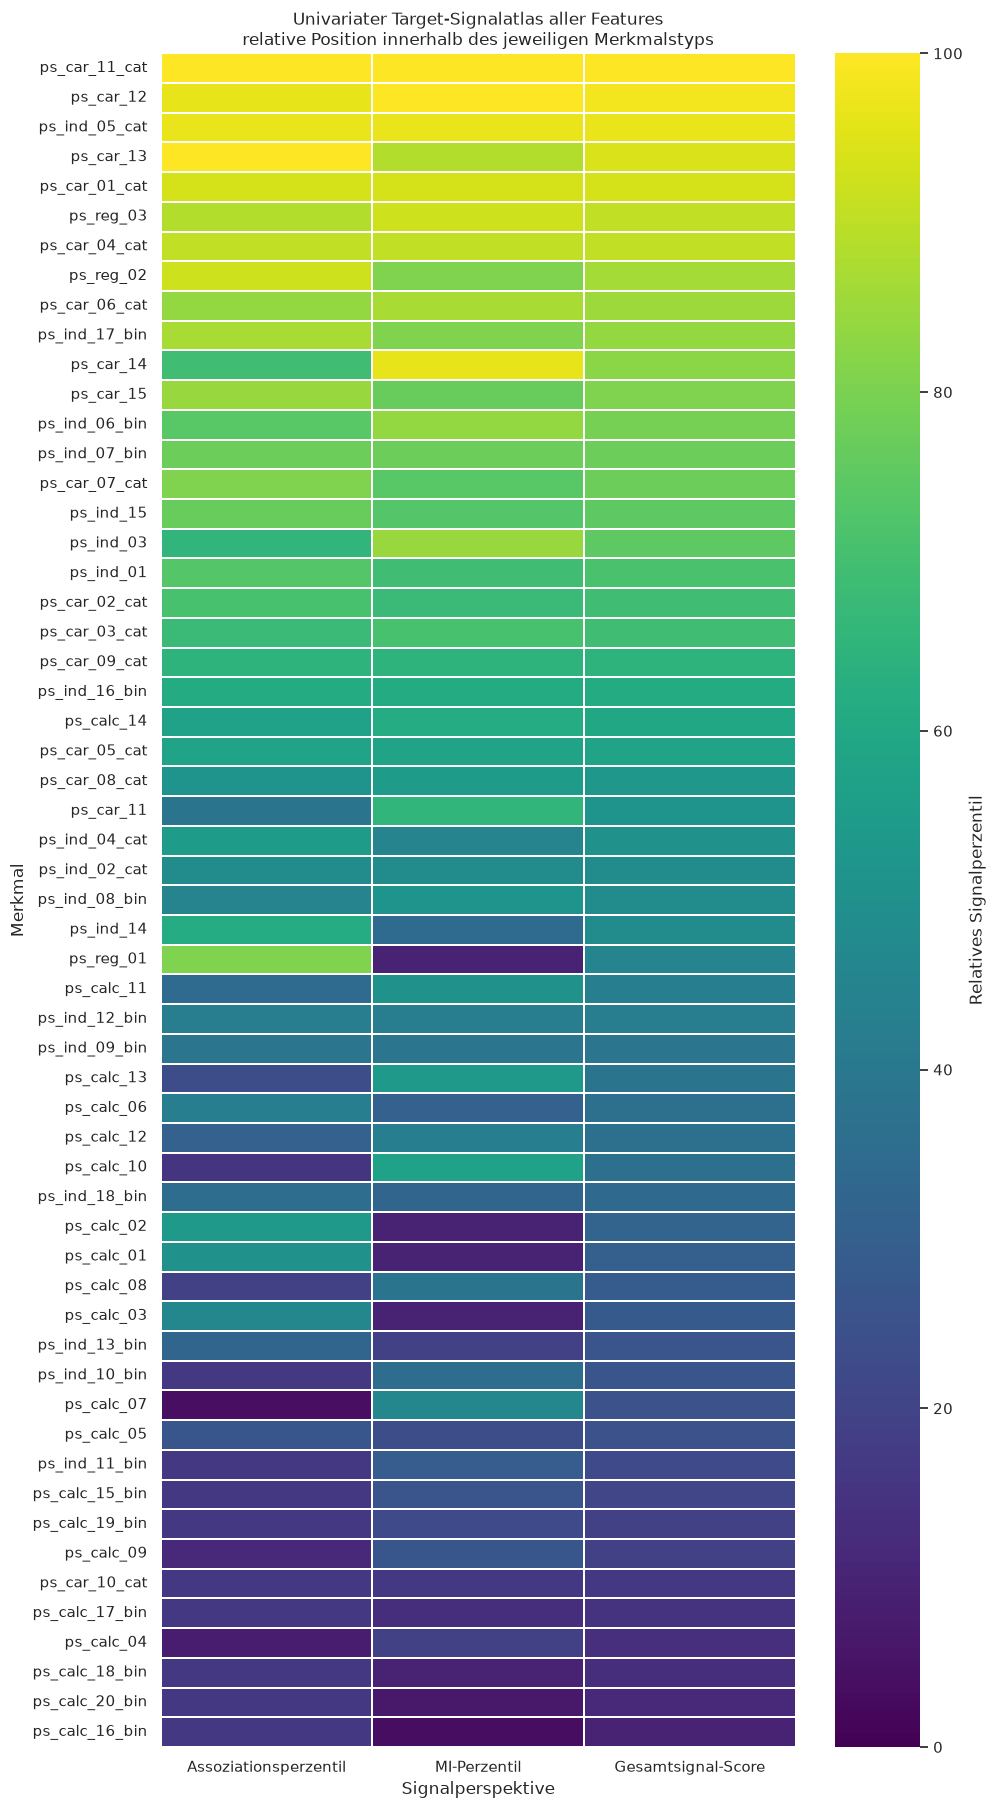

In [152]:
# Heatmap

signal_heatmap_data = (
    feature_target_signal_table
    .set_index("Merkmal")[
        [
            "Assoziationsperzentil",
            "MI-Perzentil",
            "Gesamtsignal-Score",
        ]
    ]
    .sort_values(
        "Gesamtsignal-Score",
        ascending=False,
    )
)

figure_height = max(
    10,
    len(signal_heatmap_data) * 0.32,
)

plt.figure(
    figsize=(10, figure_height)
)

sns.heatmap(
    signal_heatmap_data,
    cmap="viridis",
    vmin=0,
    vmax=100,
    linewidths=0.25,
    cbar_kws={
        "label": "Relatives Signalperzentil",
    },
)

plt.title(
    "Univariater Target-Signalatlas aller Features\n"
    "relative Position innerhalb des jeweiligen Merkmalstyps"
)
plt.xlabel("Signalperspektive")
plt.ylabel("Merkmal")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "complete_feature_target_signal_heatmap_exp8.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## 09. Binärfeatures und Schadensquote (Nachtrag zu 2)

In [153]:
binary_target_rows = []

for feature in binary_features:
    feature_values = pd.to_numeric(
        train_df[feature].astype("string"),
        errors="coerce",
    )

    valid_mask = (
        feature_values.isin([0, 1])
        & train_df[target_column].notna()
    )

    feature_target_data = pd.DataFrame(
        {
            "Featurewert": feature_values[valid_mask].astype(int),
            target_column: (
                train_df.loc[
                    valid_mask,
                    target_column,
                ]
                .astype(int)
            ),
        }
    )

    grouped = (
        feature_target_data
        .groupby(
            "Featurewert",
            observed=True,
        )[target_column]
        .agg(
            Anzahl="size",
            Schadenfälle="sum",
            Schadensquote="mean",
        )
        .reindex([0, 1])
    )

    n_zero = grouped.loc[0, "Anzahl"]
    n_one = grouped.loc[1, "Anzahl"]

    rate_zero = grouped.loc[0, "Schadensquote"]
    rate_one = grouped.loc[1, "Schadensquote"]

    binary_target_rows.append(
        {
            "Merkmal": feature,
            "Anzahl Wert 0": n_zero,
            "Anzahl Wert 1": n_one,
            "Anteil Wert 1 (%)": (
                n_one
                / (n_zero + n_one)
                * 100
            ),
            "Schadensquote Wert 0 (%)": (
                rate_zero * 100
            ),
            "Schadensquote Wert 1 (%)": (
                rate_one * 100
            ),
            "Differenz 1 minus 0 (pp)": (
                (rate_one - rate_zero) * 100
            ),
            "Relatives Risiko 1 zu 0": (
                rate_one / rate_zero
                if rate_zero > 0
                else np.nan
            ),
        }
    )

In [154]:
binary_target_overview = (
    pd.DataFrame(binary_target_rows)
    .assign(
        **{
            "Absolute Differenz (pp)": (
                lambda frame: frame[
                    "Differenz 1 minus 0 (pp)"
                ].abs()
            )
        }
    )
    .sort_values(
        "Absolute Differenz (pp)",
        ascending=False,
    )
    .reset_index(drop=True)
)

In [155]:
binary_target_overview.to_csv(
    OUTPUT_DIR
    / "binary_feature_target_overview_exp10.csv",
    index=False,
    encoding="utf-8",
)

display(
    binary_target_overview.round(4)
)

,Merkmal,Anzahl Wert 0,Anzahl Wert 1,Anteil Wert 1 (%),Schadensquote Wert 0 (%),Schadensquote Wert 1 (%),Differenz 1 minus 0 (pp),Relatives Risiko 1 zu 0,Absolute Differenz (pp)
0,ps_ind_17_bin,418446,57722,12.1222,3.3837,5.5386,2.1549,1.6368,2.1549
1,ps_ind_12_bin,471657,4511,0.9474,3.6295,5.2538,1.6243,1.4475,1.6243
2,ps_ind_07_bin,353821,122347,25.6941,3.2629,4.7496,1.4867,1.4556,1.4867
3,ps_ind_06_bin,288771,187397,39.3552,4.1680,2.8389,-1.3291,0.6811,1.3291
4,ps_ind_10_bin,475981,187,0.0393,3.6445,4.8128,1.1684,1.3206,1.1684
5,ps_ind_16_bin,161484,314684,66.0868,4.3620,3.2769,-1.0851,0.7512,1.0851
6,ps_ind_13_bin,475714,454,0.0953,3.6440,4.6256,0.9816,1.2694,0.9816
7,ps_ind_08_bin,397981,78187,16.4200,3.5379,4.1900,0.6521,1.1843,0.6521
8,ps_ind_11_bin,475368,800,0.1680,3.6441,4.1250,0.4809,1.1320,0.4809
9,ps_ind_09_bin,387931,88237,18.5306,3.7138,3.3421,-0.3717,0.8999,0.3717


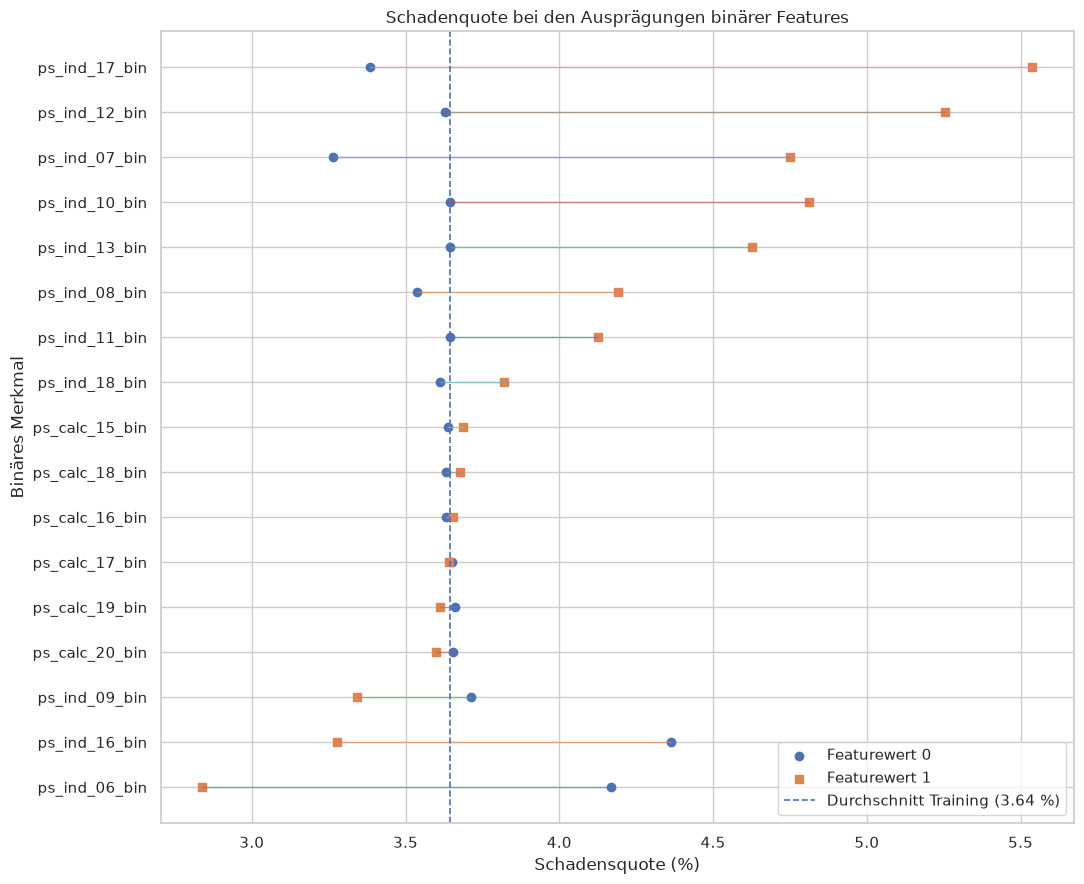

In [156]:
# Plot
binary_plot_data = (
    binary_target_overview
    .sort_values(
        "Differenz 1 minus 0 (pp)",
        ascending=True,
    )
    .reset_index(drop=True)
)

positions = np.arange(
    len(binary_plot_data)
)

fig, ax = plt.subplots(
    figsize=(11, 9)
)

for position, row in binary_plot_data.iterrows():
    ax.plot(
        [
            row["Schadensquote Wert 0 (%)"],
            row["Schadensquote Wert 1 (%)"],
        ],
        [
            position,
            position,
        ],
        linewidth=1,
        alpha=0.6,
    )

ax.scatter(
    binary_plot_data[
        "Schadensquote Wert 0 (%)"
    ],
    positions,
    marker="o",
    label="Featurewert 0",
)

ax.scatter(
    binary_plot_data[
        "Schadensquote Wert 1 (%)"
    ],
    positions,
    marker="s",
    label="Featurewert 1",
)

global_claim_rate = (
    train_df[target_column].mean() * 100
)

ax.axvline(
    global_claim_rate,
    linestyle="--",
    linewidth=1.2,
    label=(
        "Durchschnitt Training "
        f"({global_claim_rate:.2f} %)"
    ),
)

ax.set_yticks(positions)
ax.set_yticklabels(
    binary_plot_data["Merkmal"]
)

ax.set(
    title=(
        "Schadenquote bei den Ausprägungen "
        "binärer Features"
    ),
    xlabel="Schadensquote (%)",
    ylabel="Binäres Merkmal",
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "binary_feature_target_dumbbell_exp10.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## 10. Gemeinsame Risikostruktur korrelierter numerischer Features

In [157]:
minimum_cell_count = 500
requested_quantiles = 8

pair_target_tables = {}
pair_plot_results = []
quantile_diagnostics = []

In [159]:
correlated_pairs = [
    ("ps_car_12", "ps_car_13"),
    ("ps_reg_01", "ps_reg_03"),
    ("ps_reg_02", "ps_reg_03"),
]

In [160]:
for x_feature, y_feature in correlated_pairs:
    pair_data = (
        train_df[
            [
                x_feature,
                y_feature,
                target_column,
            ]
        ]
        .dropna()
        .copy()
    )

    x_quantiles, x_edges = pd.qcut(
        pair_data[x_feature],
        q=requested_quantiles,
        labels=False,
        duplicates="drop",
        retbins=True,
    )

    y_quantiles, y_edges = pd.qcut(
        pair_data[y_feature],
        q=requested_quantiles,
        labels=False,
        duplicates="drop",
        retbins=True,
    )

    pair_data["x_quantile"] = x_quantiles + 1
    pair_data["y_quantile"] = y_quantiles + 1

    effective_x_quantiles = len(x_edges) - 1
    effective_y_quantiles = len(y_edges) - 1

    quantile_diagnostics.append(
        {
            "Featurepaar": f"{x_feature} × {y_feature}",
            "X-Feature": x_feature,
            "Effektive X-Quantile": effective_x_quantiles,
            "Y-Feature": y_feature,
            "Effektive Y-Quantile": effective_y_quantiles,
            "Eindeutige X-Werte": pair_data[x_feature].nunique(),
            "Eindeutige Y-Werte": pair_data[y_feature].nunique(),
        }
    )

    pair_target_table = (
        pair_data
        .groupby(
            ["y_quantile", "x_quantile"],
            observed=True,
        )
        .agg(
            Anzahl=(target_column, "size"),
            Schadensquote=(target_column, "mean"),
        )
        .reset_index()
    )

    pair_target_table["Schadensquote (%)"] = (
        pair_target_table["Schadensquote"] * 100
    )

    pair_target_tables[f"{x_feature}__{y_feature}"] = pair_target_table

    claim_rate_matrix = pair_target_table.pivot(
        index="y_quantile",
        columns="x_quantile",
        values="Schadensquote (%)",
    )

    count_matrix = pair_target_table.pivot(
        index="y_quantile",
        columns="x_quantile",
        values="Anzahl",
    )

    insufficient_data_mask = (
        count_matrix
        .reindex_like(claim_rate_matrix)
        .lt(minimum_cell_count)
    )

    pearson_r = (
        pair_data[[x_feature, y_feature]]
        .corr(method="pearson")
        .iloc[0, 1]
    )

    pair_plot_results.append(
        {
            "x_feature": x_feature,
            "y_feature": y_feature,
            "claim_rate_matrix": claim_rate_matrix,
            "insufficient_data_mask": insufficient_data_mask,
            "pearson_r": pearson_r,
        }
    )

In [161]:
eligible_claim_rates = pd.concat(
    [
        table.loc[
            table["Anzahl"] >= minimum_cell_count,
            "Schadensquote (%)",
        ]
        for table in pair_target_tables.values()
    ],
    ignore_index=True,
)

common_vmin = eligible_claim_rates.min()
common_vmax = eligible_claim_rates.max()

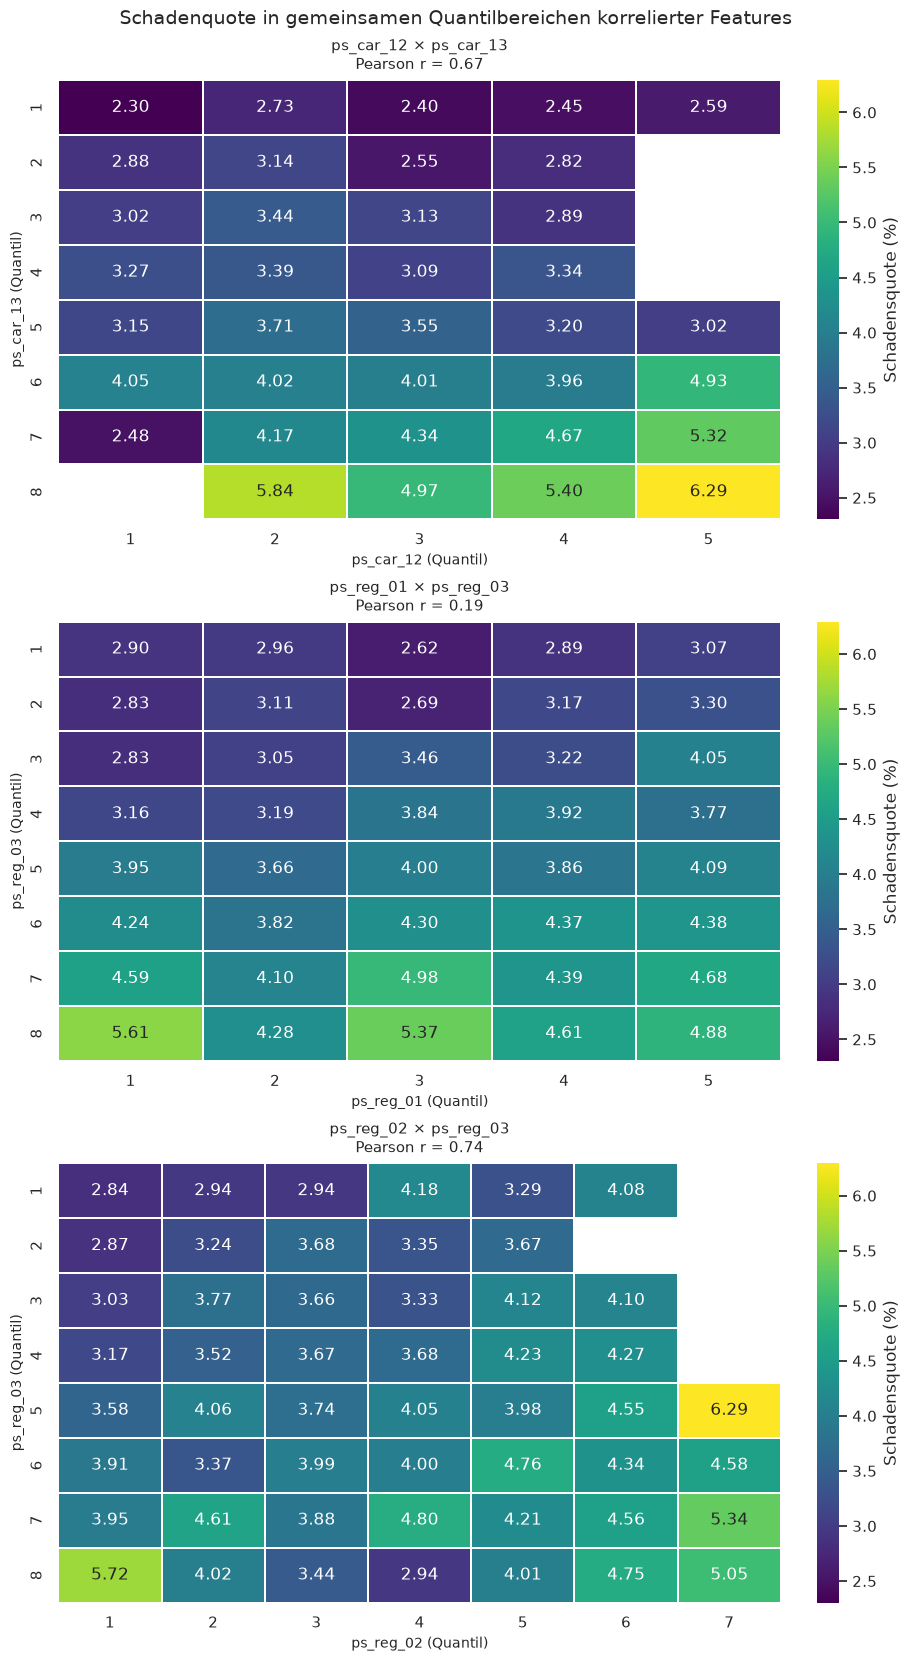

,Featurepaar,X-Feature,Effektive X-Quantile,Y-Feature,Effektive Y-Quantile,Eindeutige X-Werte,Eindeutige Y-Werte
0,ps_car_12 × ps_car_13,ps_car_12,5,ps_car_13,8,180,64097
1,ps_reg_01 × ps_reg_03,ps_reg_01,5,ps_reg_03,8,10,4976
2,ps_reg_02 × ps_reg_03,ps_reg_02,7,ps_reg_03,8,19,4976


In [162]:
with sns.axes_style("white"):
    fig, axes = plt.subplots(
        nrows=len(pair_plot_results),
        ncols=1,
        figsize=(9, 5.5 * len(pair_plot_results)),
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, result in zip(axes, pair_plot_results):
        sns.heatmap(
            result["claim_rate_matrix"],
            mask=result["insufficient_data_mask"],
            annot=True,
            fmt=".2f",
            cmap="viridis",
            vmin=common_vmin,
            vmax=common_vmax,
            linewidths=0.3,
            linecolor="white",
            cbar_kws={"label": "Schadensquote (%)"},
            ax=ax,
        )

        ax.set_title(
            f'{result["x_feature"]} × {result["y_feature"]}\n'
            f'Pearson r = {result["pearson_r"]:.2f}',
            fontsize=11,
            pad=8,
        )

        ax.set_xlabel(
            f'{result["x_feature"]} (Quantil)',
            fontsize=10,
        )
        ax.set_ylabel(
            f'{result["y_feature"]} (Quantil)',
            fontsize=10,
        )

        ax.grid(False)
        ax.set_facecolor("white")

    fig.suptitle(
        "Schadenquote in gemeinsamen Quantilbereichen korrelierter Features",
        fontsize=14,
    )

    fig.savefig(
        OUTPUT_DIR / "correlated_pair_target_surfaces_exp9.pdf",
        format="pdf",
        bbox_inches="tight",
    )

    plt.show()

quantile_diagnostics = pd.DataFrame(quantile_diagnostics)
display(quantile_diagnostics)

## **Teil D - EDA Zusammenfassung und mögliche Hypothesen**

**Erkenntnisse in Stichpunkten:**

-  Der Datensatz umfasst 595.212 Beobachtungen, 57 Features und die binäre Zielvariable. Es treten weder vollständige Duplikate noch Duplikate über alle 57 Features auf. 13 Features enthalten fehlende Werte. Der Datensatz ist technisch konsistent; es ergibt sich aus der Integritätsprüfung kein unmittelbarer Grund für das Entfernen von Beobachtungen oder Features.
-  Nur rund 3,64 % der Beobachtungen gehören zur positiven Klasse. Damit handelt es sich um eine Anomoalie.
-  Fehlende Werte konzentrieren sich stark auf wenige Merkmale. Besonders betroffen sind ps_car_03_cat mit rund 69,09 %, ps_car_05_cat mit rund 44,73–44,78 %, ps_reg_03 mit rund 18,16 % und ps_car_14 mit rund 7,14 %. Ein pauschales Löschen aller unvollständigen Beobachtungen würde einen großen Teil des Datensatzes entfernen. Ebenso ist ein automatischer Ausschluss stark betroffener Features nicht gerechtfertigt, solange deren Informationsgehalt nicht untersucht wurde.
-  Missingness ist teilweise targetabhängig, jedoch nicht in einheitlicher Richtung. Bei fehlendem ps_car_07_cat beträgt die Schadensquote beispielsweise rund 7,78% gegenüber 3,56% bei vorhandenem Wert (+4,21%). Bei ps_car_03_cat, ps_car_05_cat und ps_reg_03 ist die Schadensquote bei fehlendem Wert dagegen niedriger als bei vorhandenem Wert. Fehlende Werte können so potenziell selber Informationsgehalt in sich tragen
-  Die Schadensquote steigt nicht monoton mit der Zahl fehlender Features. Im Training beträgt sie bei 0, 1, 2, 3 und 4 fehlenden Features etwa 4,52%, 3,64%, 3,40%, 2,84% und 2,09%. Die Gruppe mit mindestens fünf fehlenden Features weist zwar 36,21 % auf, besteht aber lediglich aus 58 Beobachtungen.
- Die kategorialen Features unterscheiden sich stark in ihrer Kardinalität. ps_car_11_cat besitzt 104 Kategorien und ist damit das am höchsten kardinale kategoriale Merkmal; die kleinste Kategorie umfasst im Training dennoch 889 Beobachtungen. Eine einheitliche Repräsentation aller kategorialen Features ist nicht zwingend optimal, wenn ps_car_11_cat den Merkmalsraum sehr stark aufbläht. Ggf. Target-Encoding verwenden?
- Kein einzelnes Feature zeigt einen starken isolierten Zusammenhang mit dem Target. Der höchste absolute punktbiseriale Zusammenhang der numerisch/ordinalen Merkmale liegt bei ps_car_13 mit etwa 0,0543; der höchste korrigierte Cramérs-V-Wert der diskreten Merkmale bei ps_car_11_cat mit etwa 0,0490. Die Mutual Information erreicht maximal etwa 0,0039.
-  Im kombinierten univariaten Signalatlas liegt ps_car_11_cat auf Rang 1, gefolgt von ps_car_12, ps_ind_05_cat, ps_car_13, ps_car_01_cat und ps_reg_03. Dabei ist ps_car_13 unter den numerischen Features nach absoluter punktbiserialer Korrelation am stärksten. Ggf. lohnt sich ein Ablationstest (mit/ohne) um zu besetimmen welche Features man außen vor lassen kann und welche nicht
-  Die 20 ps_calc_*-Features zeigen im Mutual-Information-Screening nahezu kein direktes univariates Target-Signal.  Die Familie erscheint hinsichtlich direkter Einzelzusammenhänge deutlich targetferner als die übrigen Featuregruppen. Mutual Information eines einzelnen Features erfasst jedoch keine möglichen Interaktionen
-  Für jede Trainingsbeobachtung gilt exakt ps_ind_06_bin + ps_ind_07_bin + ps_ind_08_bin + ps_ind_09_bin = 1. Die vier Merkmale sollten für lineare Modelle damit gesondert behandelt werden um keine Multi-Kollinearität zu begünstigen
- Zwischen ps_ind_10_bin bis ps_ind_13_bin treten sehr kleine XOR-Distanzen auf. Die sehr hohe Gesamtübereinstimmung entsteht allerdings v.a. durch die Seltenheit der Einsen und die daraus resultierenden gemeinsamen Nullen. Sie stellt deshalb keine Evidenz für Redundanz dar
- Einzelne binäre Merkmale zeigen deutlich unterschiedliche Schadensquoten zwischen Wert 0 und 1. Besonders ausgeprägt sind die Differenzen bei ps_ind_17_bin (+2,15%), ps_ind_12_bin (+1,62% ), ps_ind_07_bin und ps_ind_06_bin.
- ps_car_12, ps_car_13 und ps_reg_03 besitzen als numerisch deklarierte Features ungewöhnlich strukturierte Wertebereiche, womöglich sind sie künstlichen Transformationen unterworfen.
